# 🌾 Trực Quan Hóa Dữ Liệu Nông Nghiệp — Visualization Only
## Bangladesh · 64 huyện · 3 mùa vụ · 72 loại cây trồng

---

> **Notebook thuần Data Visualization.** Đặt `Agri_Data_Cleaned.csv` cùng thư mục rồi chạy tuần tự từ trên xuống.

| Phần | Nội dung |
|---|---|
| **D** | Phân bố dữ liệu theo nhóm |
| **E** | Phân phối các biến chính |
| **F** | Ảnh hưởng Mùa vụ & Cây trồng |
| **G** | Quan hệ Khí hậu/Viễn thám → Năng suất |
| **H** | Ngưỡng rủi ro nắng nóng |
| **I** | Xếp hạng Huyện |
| **J** | Bản đồ nhiệt Huyện × Mùa vụ |
| **K** | Ma trận tương quan |
| **L** | Biểu đồ bong bóng đa biến |
| **N** | Pareto 80/20 |
| **O** | Radar chart — Hồ sơ đất |
| **P** | Biểu đồ tương tác (Plotly) |
| **Q** | Bản đồ địa lý |
| **R** | PCA — Cấu trúc đa biến |
| **S** | Kết luận & Xuất file |


## Phần 1 — Cài đặt thư viện, Màu sắc & Hàm tiện ích

In [1]:
# ============================================================
# PHẦN 1 — THƯ VIỆN, CẤU HÌNH TOÀN CỤC & HÀM TIỆN ÍCH
# ============================================================
# Chạy cell này TRƯỚC TIÊN — tất cả các phần phía dưới đều phụ thuộc vào đây.
#
# Thư viện bổ sung (cài 1 lần):
#   pip install plotly shap missingno

import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- Plotly (biểu đồ tương tác) ---
try:
    import plotly.express as px
    import plotly.graph_objects as go
    HAS_PLOTLY = True
    print("✅  Plotly sẵn sàng — biểu đồ tương tác được bật.")
except ImportError:
    HAS_PLOTLY = False
    print("ℹ️  Chưa có Plotly. Cài bằng: pip install plotly")

# --- SHAP (giải thích mô hình) ---
try:
    import shap
    HAS_SHAP = True
    print("✅  SHAP sẵn sàng — phân tích độ quan trọng biến nâng cao được bật.")
except ImportError:
    HAS_SHAP = False
    print("ℹ️  Chưa có SHAP. Cài bằng: pip install shap")

# --- missingno (trực quan hóa giá trị thiếu) ---
try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False

# ── Giao diện đồ thị mặc định ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,       # Chất lượng xuất báo cáo
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Bảng màu mùa vụ (thân thiện với người mù màu — Paul Tol Bright) ──────
# Xanh/Hồng/Vàng: phân biệt được với cả 3 dạng mù màu phổ biến nhất.
SEASON_PALETTE = {
    "Kharif 1": "#4477AA",   # Xanh dương  — vụ hè 1
    "Kharif 2": "#EE6677",   # Hồng/đỏ    — vụ hè 2
    "Rabi":     "#CCBB44",   # Vàng        — vụ đông
}

def season_palette(series: pd.Series) -> dict:
    '''Tra ve dict mau cho cac mua.'''
    return {u: SEASON_PALETTE.get(u, "#AAAAAA") for u in series.dropna().unique()}

# ── Bảng đơn vị đo lường ─────────────────────────────────────────────────
DON_VI = {
    "Area": "ha", "Avg Temp": "°C", "Max Temp": "°C", "Min Temp": "°C",
    "LST_C": "°C", "Rainfall": "mm", "Soil_Moisture_mm": "mm",
    "Heat_Stress_Days": "ngày", "Production": "tấn (ước tính)",
    "Yield": "tấn/ha", "Calc_Yield": "Sản lượng / Diện tích",
    "Organic_Carbon": "g/kg", "Nitrogen": "mg/kg",
    "Bulk_Density": "g/cm³", "Moisture_Ratio": "không thứ nguyên", "pH": "không thứ nguyên",
}

def ten_dep(col: str) -> str:
    '''Chuyen ten cot ky thuat sang ten dep.'''
    VIET_MAP = {
        "NDVI_Season_Mean":"NDVI Trung bình Mùa","Avg Temp":"Nhiệt độ TB",
        "Rainfall":"Lượng mưa","Heat_Stress_Days":"Ngày Nắng nóng",
        "Soil_Moisture_mm":"Độ ẩm đất","Organic_Carbon":"Carbon hữu cơ",
        "Nitrogen":"Đạm (N)","pH":"Độ pH","Clay":"Đất sét (Clay)",
        "Sand":"Cát (Sand)","Silt":"Thịt (Silt)","Bulk_Density":"Dung trọng đất",
        "Production":"Sản lượng","Yield":"Năng suất","Area":"Diện tích",
        "Calc_Yield":"Năng suất tính toán","Season":"Mùa vụ",
        "District":"Huyện","Crop Name":"Cây trồng",
        "Dominant_Soil_Texture":"Kết cấu đất chủ đạo",
        "Water_Availability_Cat":"Mức nước sẵn có",
        "Extreme_Heat_Risk":"Rủi ro nắng nóng cực đoan",
        "EVI":"EVI","LAI":"LAI","FPAR":"FPAR","LST_C":"Nhiệt độ bề mặt (LST)",
        "Avg_Salinity_Index":"Chỉ số mặn TB",
        "Moisture_Ratio":"Tỷ lệ ẩm","Avg Humidity":"Độ ẩm không khí TB",
    }
    return VIET_MAP.get(col, col.replace("_"," ").title())

def nhan_truc(col: str) -> str:
    '''Tra ve nhan truc Dep (don vi) hoac Dep.'''
    base = ten_dep(col)
    unit = DON_VI.get(col)
    return f"{base} ({unit})" if unit else base

def fmt_nghin(x, pos=None) -> str:
    '''Định dạng số lớn: 1234567 -> '1,234,567'.'''
    try: return f"{int(x):,}"
    except: return str(x)

def despine(ax=None):
    '''Xóa viền trên/phải; làm mờ viền còn lại.'''
    sns.despine(ax=ax, top=True, right=True)
    if ax is not None:
        for s in ("left","bottom"): ax.spines[s].set_alpha(0.4)

def kiem_tra_cot(cots: list, phan: str, df_ref=None) -> bool:
    '''
    Kiểm tra cột tồn tại trước khi vẽ.
    In cảnh báo rõ ràng (không bỏ qua im lặng) nếu thiếu cột.
    '''
    ref = df_ref if df_ref is not None else globals().get("df", pd.DataFrame())
    thieu = [c for c in cots if c not in ref.columns]
    if thieu:
        print(f"⚠️  [{phan}] BỎ QUA — thiếu cột: {thieu}")
        return False
    return True

def chon_cot_ve(col: str, df_ref=None, nguong_lech=1.0):
    '''
    Tự động chọn cột log nếu |độ lệch| >= ngưỡng và cột log tồn tại.
    Kiểm tra giá trị âm trước khi log1p.
    '''
    ref = df_ref if df_ref is not None else globals().get("df", pd.DataFrame())
    if col not in ref.columns: return col
    do_lech = ref[col].skew()
    log_col = f"log_{col}".replace(" ","_")
    if abs(do_lech) >= nguong_lech:
        if log_col in ref.columns:
            return log_col
        min_val = ref[col].min(skipna=True)
        if pd.notna(min_val) and min_val >= -1:
            ref[log_col] = np.log1p(ref[col])
            return log_col
        else:
            print(f"⚠️  [{col}] Lệch mạnh (skew={do_lech:.2f}) nhưng giá trị min={min_val:.4g} < -1 → không thể log1p.")
    return col



✅  Plotly sẵn sàng — biểu đồ tương tác được bật.
✅  SHAP sẵn sàng — phân tích độ quan trọng biến nâng cao được bật.


## Phần A — Đọc Dữ Liệu & Kiểm Tra Kiểu Dữ Liệu

**Mục tiêu:** Đảm bảo dữ liệu được đọc đúng encoding và tất cả cột số được nhận dạng là số (không phải chuỗi).

**Tại sao quan trọng:** Cột bị đọc sai thành kiểu `object` sẽ bị bỏ qua trong tính toán tương quan, mô hình, và biểu đồ — gây ra lỗi ngầm rất khó phát hiện sau này.


In [2]:
# ============================================================
# PHẦN A — ĐỌC DỮ LIỆU & KIỂM TRA KIỂU DỮ LIỆU
# ============================================================

from pathlib import Path

DUONG_DAN = Path("Agri_Data_Cleaned.csv")
df = pd.read_csv(DUONG_DAN, encoding="utf-8-sig")  # utf-8-sig xử lý BOM của Excel

print(f"✅  Đọc xong: {DUONG_DAN.name}")
print(f"    Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột")
display(df.head(3))

print("\n─── Tổng quan kiểu dữ liệu (df.info) ───")
df.info(verbose=True, show_counts=True)

# Ép kiểu các cột số bị đọc nhầm thành chuỗi
COT_SO_CAN = [
    "Area","Production","Yield",
    "Rainfall","Avg Temp","Max Temp","Min Temp","Avg Humidity",
    "Max Relative Humidity","Min Relative Humidity",
    "Heat_Stress_Days","Wind_Mean","Wind_Max","Rain_Temp_Ratio",
    "NDVI_Season_Mean","NDVI_Season_Max","NDVI_Season_Min",
    "NDVI_Season_Std","NDVI_Season_Range","NDVI_Season_CV",
    "EVI","LAI","FPAR","LST_C",
    "Soil_Moisture_mm","sm_surface","sm_rootzone","Rootzone_Surface_Diff",
    "Moisture_Ratio","Avg_Salinity_Index",
    "pH","Organic_Carbon","Nitrogen","Clay","Sand","Silt","Bulk_Density","CN_Ratio",
]
da_ep = []
for col in COT_SO_CAN:
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = pd.to_numeric(df[col], errors="coerce")
        da_ep.append(col)

print(f"\n🔧  Đã ép kiểu số cho {len(da_ep)} cột." if da_ep
      else "\nℹ️   Tất cả cột đã đúng kiểu số — không cần ép thêm.")


✅  Đọc xong: Agri_Data_Cleaned.csv
    Kích thước: 4,178 dòng × 51 cột


,Area,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,...,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat,LST_C,is_extreme_Heat_Stress_Days,is_extreme_Wind_Max,Yield
0,259,Bagerhat,Rabi,17.75,55.0,Wheat,December,Jan To March,April,200.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,0.772201
1,421,Bagerhat,Rabi,20.50,60.0,Maize 2,December,Jan To March,April,946.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,2.247031
2,145439,Bagerhat,Rabi,26.00,72.5,Boro,November,Dec To March,April,268754.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,1.847881



─── Tổng quan kiểu dữ liệu (df.info) ───
<class 'pandas.DataFrame'>
RangeIndex: 4178 entries, 0 to 4177
Data columns (total 51 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Area                         4178 non-null   int64  
 1   District                     4178 non-null   str    
 2   Season                       4178 non-null   str    
 3   Avg Temp                     4178 non-null   float64
 4   Avg Humidity                 4178 non-null   float64
 5   Crop Name                    4178 non-null   str    
 6   Transplant                   4178 non-null   str    
 7   Growth                       4178 non-null   str    
 8   Harvest                      4178 non-null   str    
 9   Production                   4178 non-null   float64
 10  Max Temp                     4178 non-null   int64  
 11  Min Temp                     4178 non-null   float64
 12  Max Relative Humidity        4178 non-null   

## Chuẩn Bị Nhanh — Tạo cột log & Calc_Yield

> Tạo các cột phái sinh cần thiết cho visualization bên dưới.


In [3]:
# Tạo Calc_Yield nếu chưa có
if "Calc_Yield" not in df.columns and {"Production","Area"}.issubset(df.columns):
    df["Calc_Yield"] = df["Production"] / df["Area"].replace(0, np.nan)

# Tạo cột log cho biến lệch mạnh
for col in ["Production","Yield","Calc_Yield","Area","Rainfall","Heat_Stress_Days","Soil_Moisture_mm","Nitrogen"]:
    log_col = f"log_{col}"
    if col in df.columns and log_col not in df.columns:
        if df[col].min(skipna=True) >= -1:
            df[log_col] = np.log1p(df[col])

print(f"✅  Sẵn sàng — {df.shape[0]:,} dòng × {df.shape[1]} cột")


✅  Sẵn sàng — 4,178 dòng × 60 cột


## Phần D — Phân Bố Dữ Liệu Theo Nhóm

**Mục tiêu:** Trước khi so sánh giữa các nhóm, cần biết dữ liệu **phân bố đều hay lệch** giữa các mùa vụ, cây trồng, huyện. Phân bố không đều ảnh hưởng trực tiếp đến độ tin cậy của kết luận.


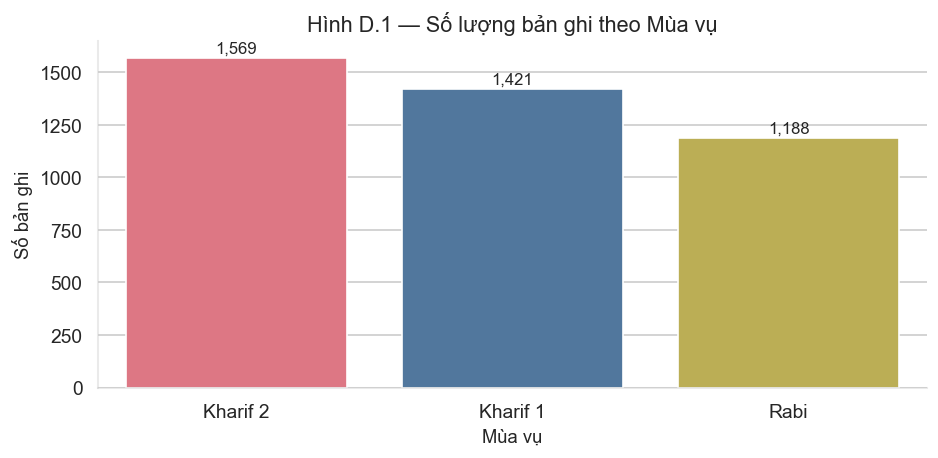

In [4]:
# D.1 — Số bản ghi theo Mùa vụ
if kiem_tra_cot(["Season"], "D.1", df):
    pal   = season_palette(df["Season"])
    order = df["Season"].value_counts().index
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.countplot(data=df, x="Season", order=order, palette=pal, ax=ax)
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0: ax.text(bar.get_x()+bar.get_width()/2, h+10, f"{int(h):,}",
                          ha="center", va="bottom", fontsize=10)
    ax.set_title("Hình D.1 — Số lượng bản ghi theo Mùa vụ", fontsize=13)
    ax.set_xlabel("Mùa vụ"); ax.set_ylabel("Số bản ghi"); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/D1_records_by_season.png", dpi=300, bbox_inches="tight")
    plt.show()


### 📝 Nhận xét — Phân bố theo Mùa vụ

**Kết quả:** Ba mùa vụ có phân bố tương đối đồng đều: Kharif 2 (1,569 bản ghi), Kharif 1 (1,421), Rabi (1,188).

**Điều cần chú ý:**  
- Rabi ít bản ghi nhất (~28%) nhưng theo dữ liệu sau sẽ thấy đây là mùa **sản lượng cao nhất** (~44% tổng sản lượng).  
- Điều này ngụ ý **quy mô canh tác trung bình trong vụ Rabi lớn hơn** hai vụ Kharif.  
- Khi so sánh trung bình giữa mùa, cần lưu ý Rabi có ít quan sát hơn -> khoảng tin cậy rộng hơn.


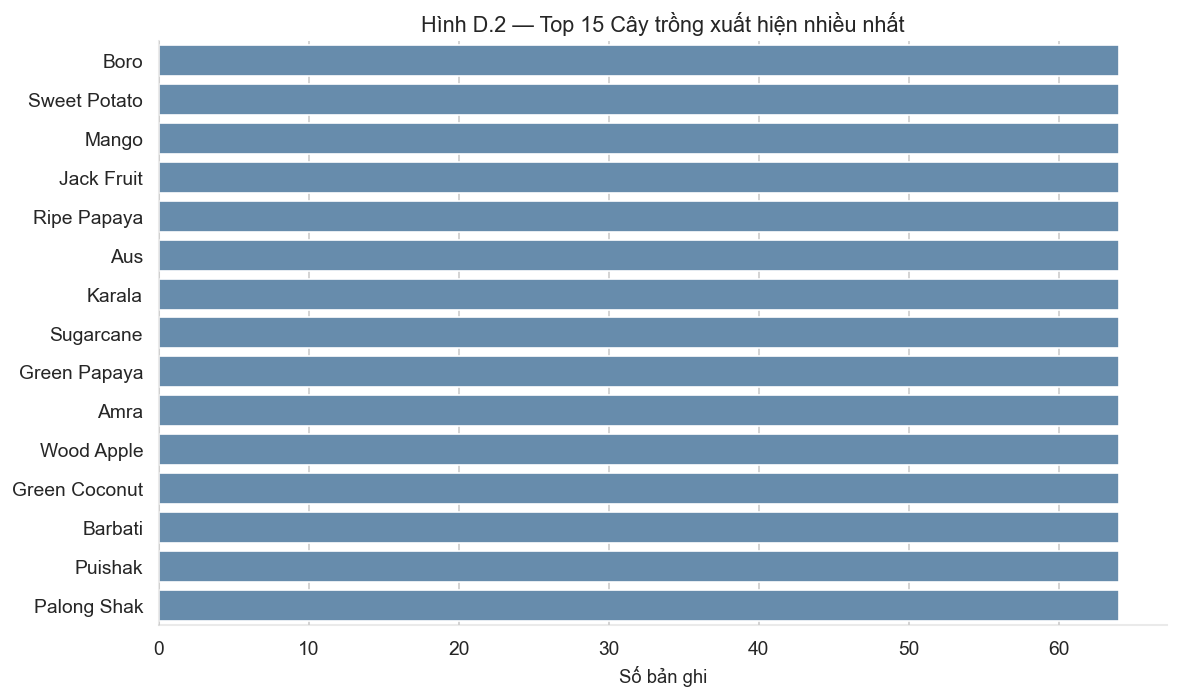

In [5]:
# D.2 — Top 15 cây trồng phổ biến nhất
if kiem_tra_cot(["Crop Name"], "D.2", df):
    top_cay = df["Crop Name"].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=top_cay.values, y=top_cay.index, ax=ax, color="#5b8db8")
    ax.set_title("Hình D.2 — Top 15 Cây trồng xuất hiện nhiều nhất", fontsize=13)
    ax.set_xlabel("Số bản ghi"); ax.set_ylabel(""); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/D2_top_crops.png", dpi=300, bbox_inches="tight")
    plt.show()


### 📝 Nhận xét — Phân bố theo Cây trồng

**Kết quả:** Tất cả 72 cây trồng đều xuất hiện đúng 64 lần (= số huyện) — bộ dữ liệu có **cấu trúc cân bằng** theo huyện-cây trồng.

**Hàm ý phân tích:**  
- Không có cây trồng nào bị "thiếu đại diện" ở cấp huyện.  
- Tuy nhiên, 72 cây trồng là con số lớn. Trong các phân tích nhóm, nên **gộp các cây ít quan trọng** thành nhóm "Khác" để tránh biểu đồ quá rối.  
- Các phân tích chính nên tập trung vào **Top 5-10 cây trồng theo sản lượng**: Boro, Aman, Đay (Jute), Ngô 2, Mía.


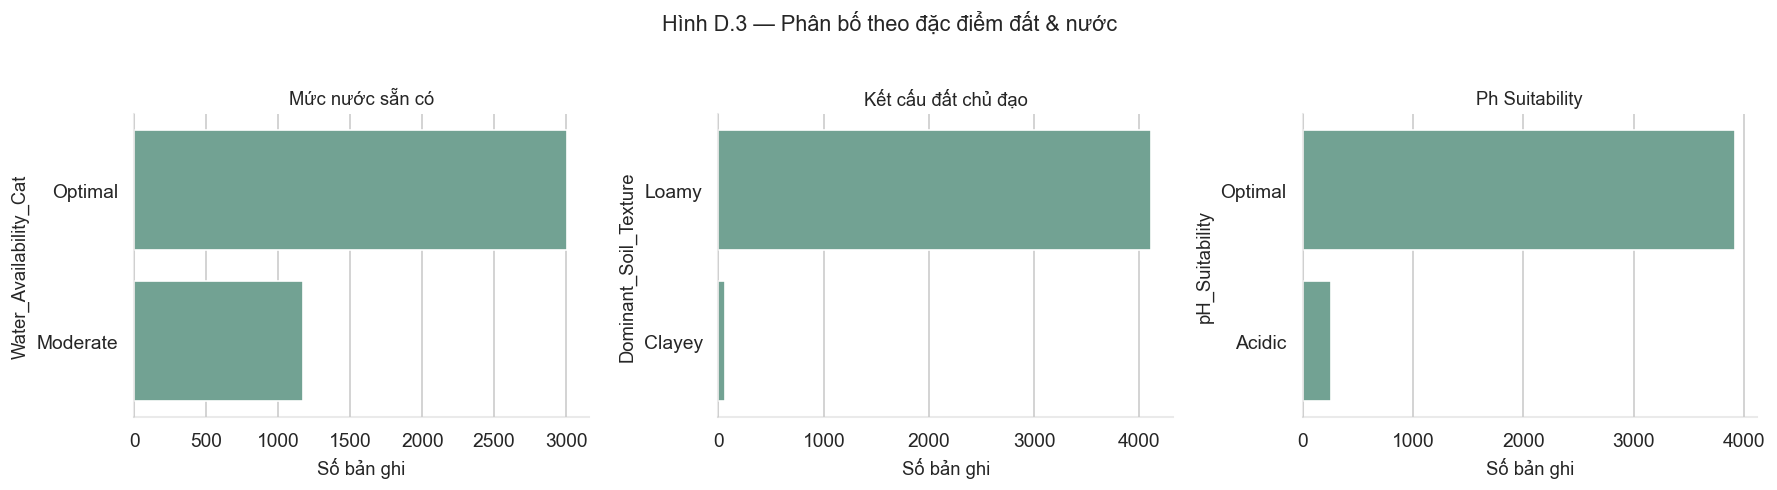

In [6]:
# D.3 — Phân bố theo Nước sẵn có & Kết cấu đất
cat_extra = [c for c in ["Water_Availability_Cat","Dominant_Soil_Texture","pH_Suitability"] if c in df.columns]
if cat_extra:
    fig, axes = plt.subplots(1, len(cat_extra), figsize=(5*len(cat_extra), 4))
    if len(cat_extra)==1: axes=[axes]
    for ax, col in zip(axes, cat_extra):
        vc = df[col].value_counts()
        sns.barplot(x=vc.values, y=vc.index, ax=ax, color="#6aaa96")
        ax.set_title(f"{ten_dep(col)}", fontsize=11)
        ax.set_xlabel("Số bản ghi"); despine(ax)
    plt.suptitle("Hình D.3 — Phân bố theo đặc điểm đất & nước", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/D3_soil_water.png", dpi=300, bbox_inches="tight")
    plt.show()


### 📝 Nhận xét — Đất & Nước

**Kết quả nổi bật:**  
- **98.4% bản ghi có đất thịt pha (Loamy)** — đất sét chiếm chưa đến 2%. Bộ dữ liệu gần như đồng nhất về kết cấu đất → **các phân tích theo kết cấu đất sẽ kém ý nghĩa** do thiếu đa dạng.  
- **72% bản ghi có nước "Tối ưu" (Optimal)**, 28% "Vừa đủ (Moderate)** — điều kiện nước nhìn chung tốt.  
- **Hàm ý:** Các yếu tố đất và nước trong bộ dữ liệu này ít biến thiên → khi chạy mô hình dự báo, độ quan trọng của biến đất thường sẽ thấp hơn biến khí hậu và viễn thám.


## Phần E — Phân Phối Các Biến Chính

**Mục tiêu:** Xem hình dạng phân phối (lệch trái/phải, đa đỉnh, cụm) trước khi đưa vào biểu đồ so sánh.  
Biến lệch mạnh được vẽ ở **thang log** để lộ ra cấu trúc ẩn.


─── Độ lệch các biến chính ───
Area                  7.940233
Production            7.490667
Yield                 5.175119
Heat_Stress_Days      1.100677
Nitrogen              1.017127
Organic_Carbon        0.823146
Rainfall              0.431658
Avg_Salinity_Index    0.201988
Soil_Moisture_mm     -0.153349
Avg Temp             -0.184812
NDVI_Season_Mean     -0.346360



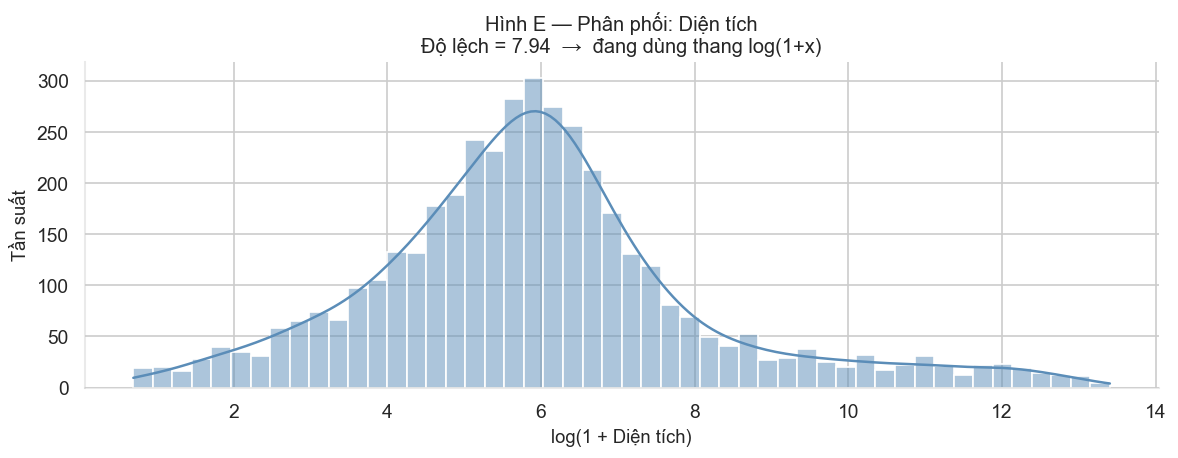

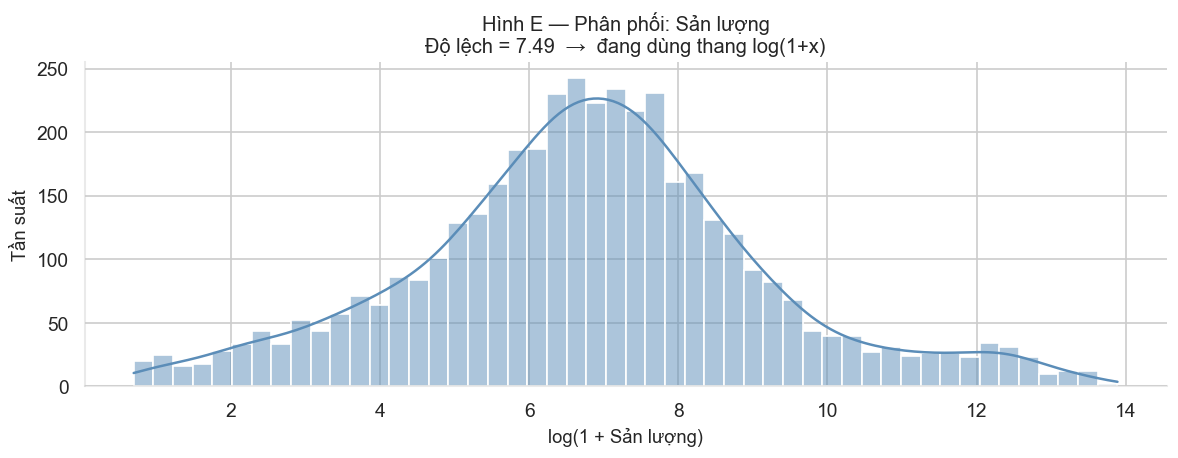

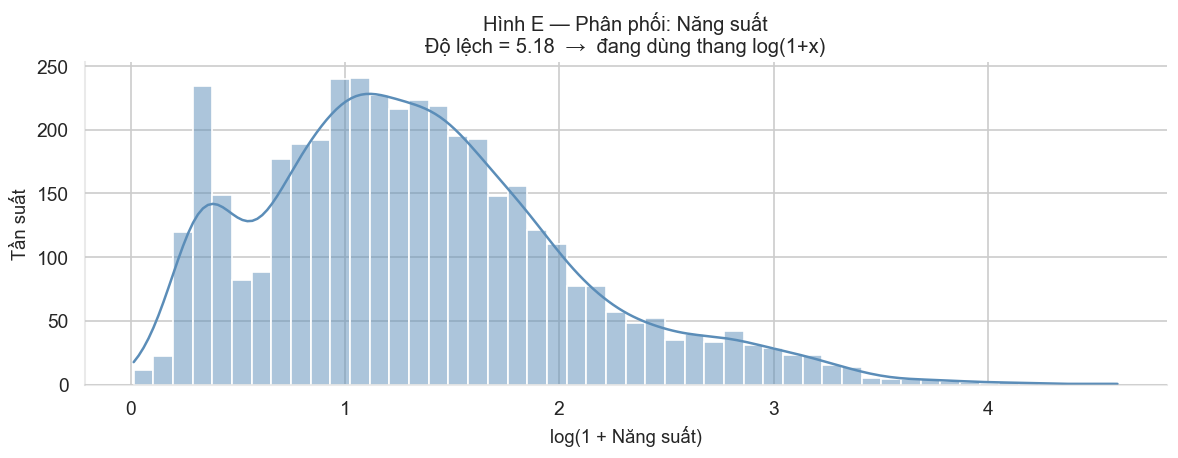

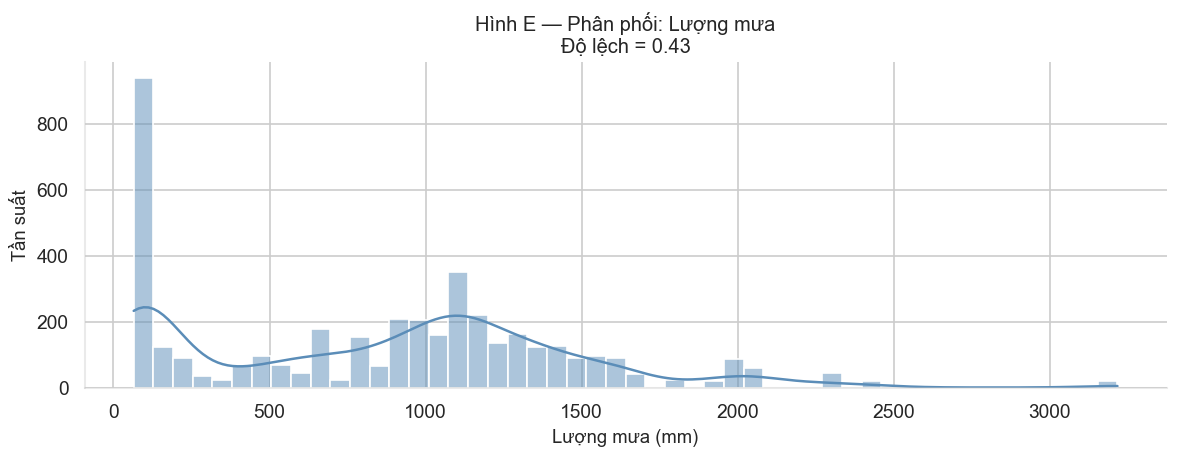

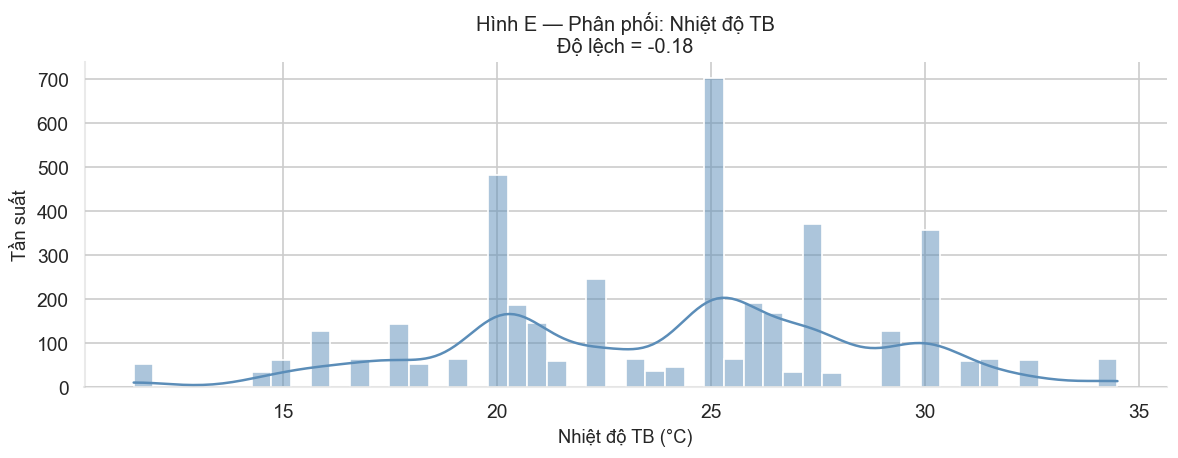

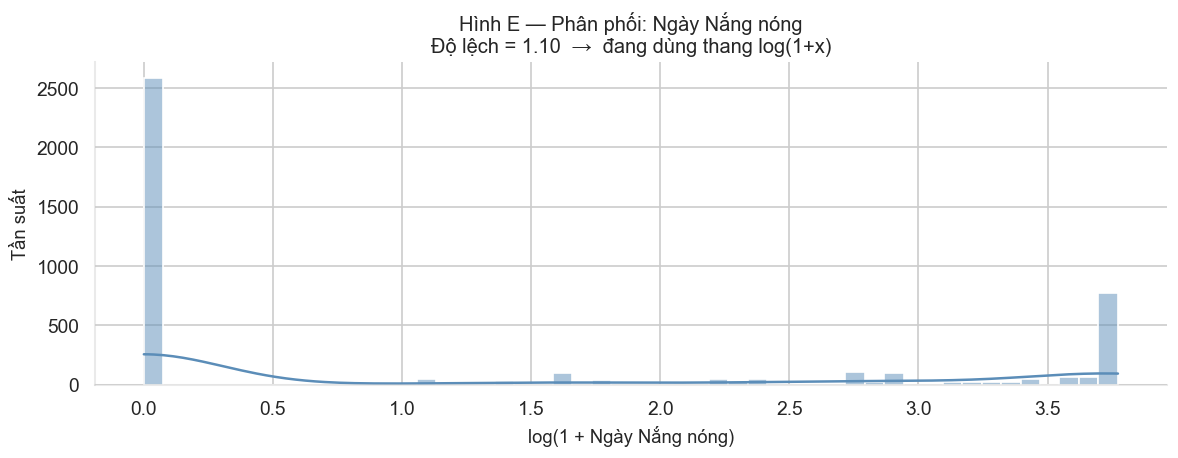

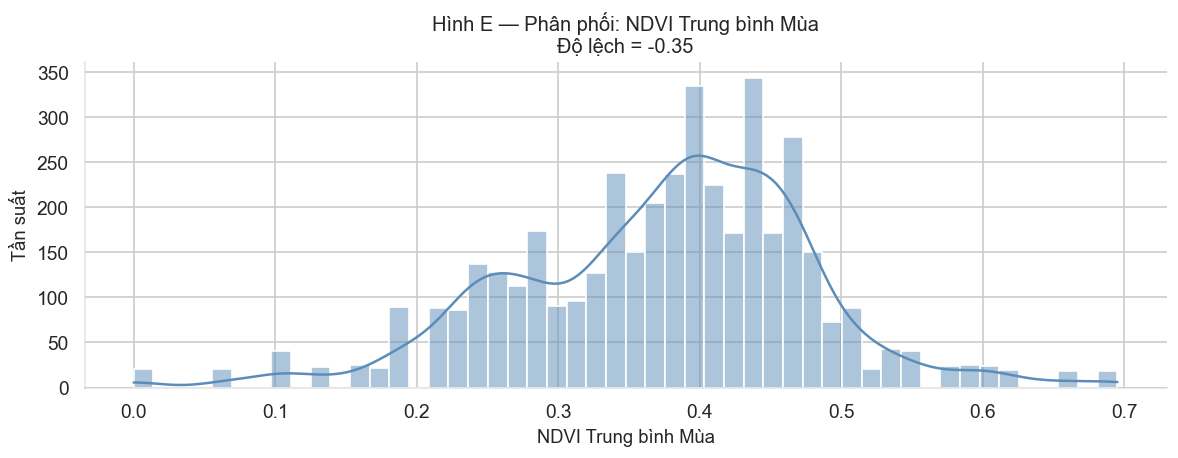

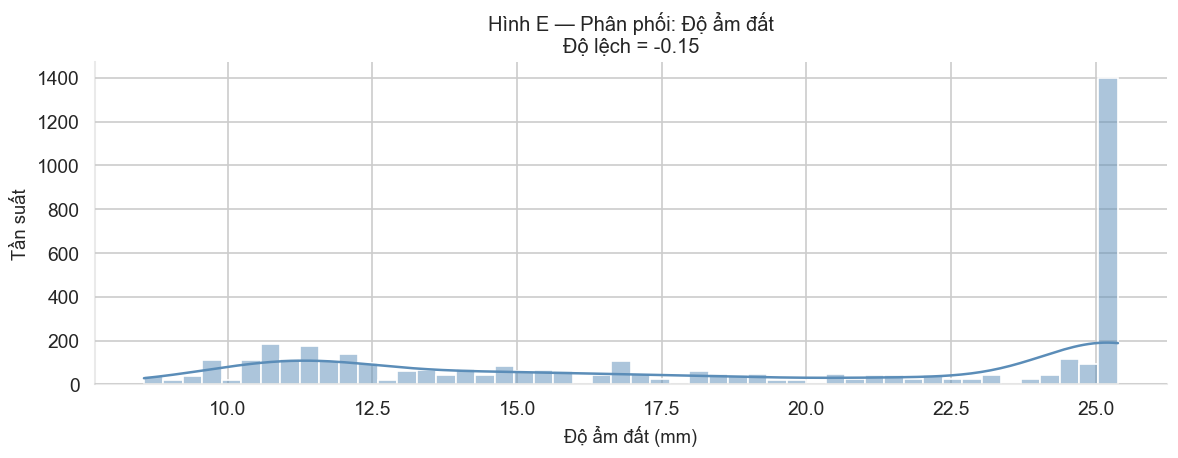

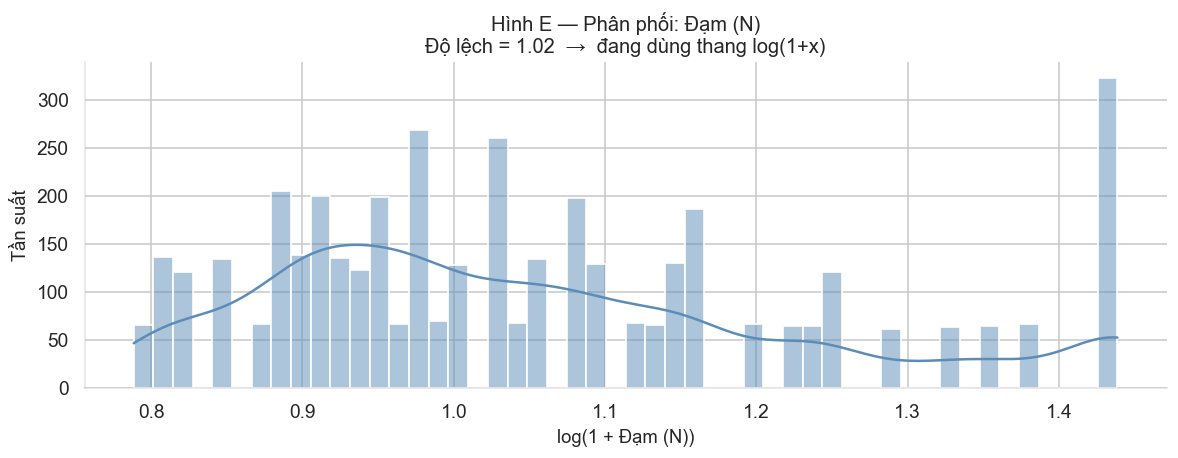

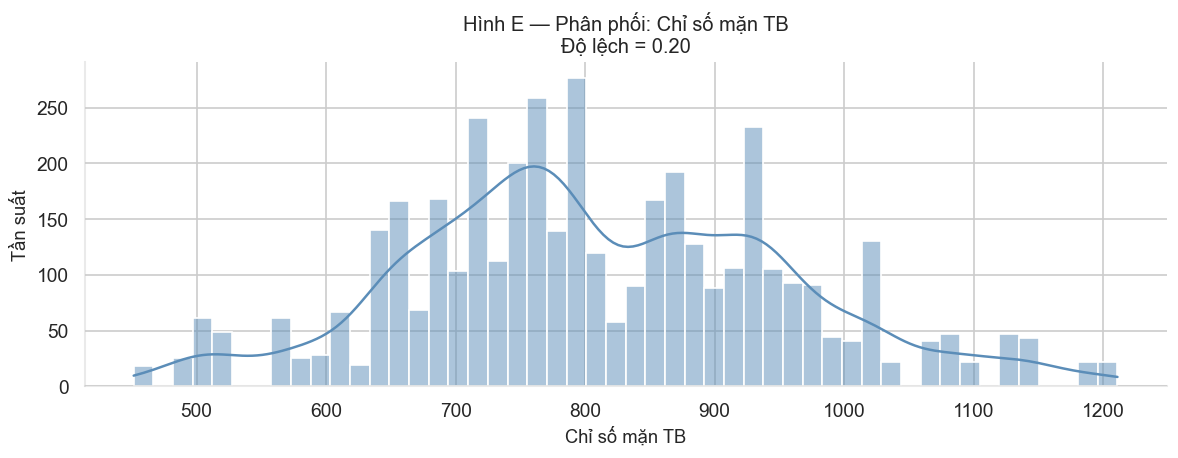

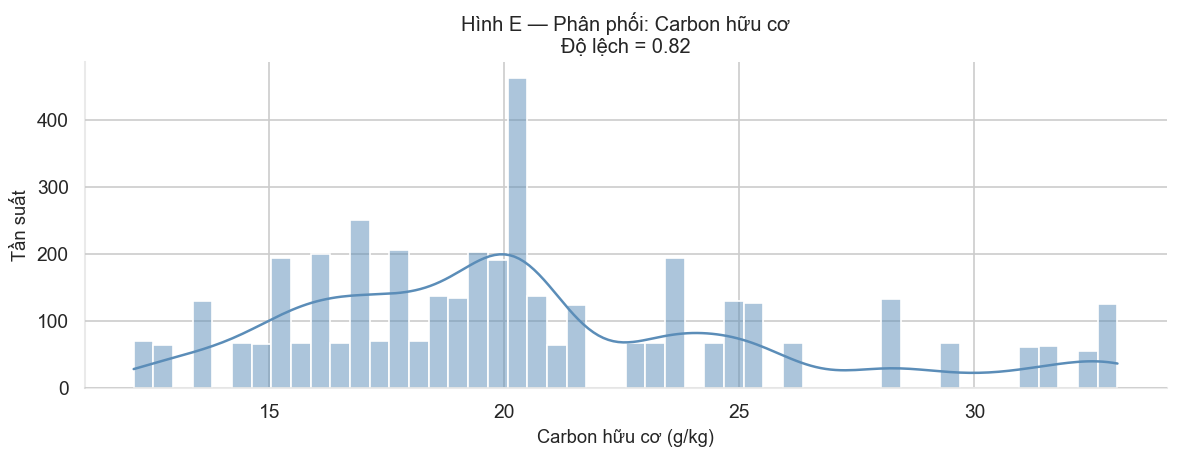

In [7]:
# E — Phân phối các biến chính (tự chọn log nếu lệch mạnh)
BIEN_PHAN_PHOI = [c for c in ["Area","Production","Yield","Rainfall","Avg Temp",
                               "Heat_Stress_Days","NDVI_Season_Mean","Soil_Moisture_mm",
                               "Nitrogen","Avg_Salinity_Index","Organic_Carbon"] if c in df.columns]
do_lech = df[BIEN_PHAN_PHOI].skew(numeric_only=True)
print("─── Độ lệch các biến chính ───")
print(do_lech.sort_values(ascending=False).to_string())
print()

for col in BIEN_PHAN_PHOI:
    ve_col   = chon_cot_ve(col)
    lech_v   = do_lech.get(col, 0)
    dung_log = ve_col != col
    nhan_x   = f"log(1 + {ten_dep(col)})" if dung_log else nhan_truc(col)

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(df[ve_col].dropna(), bins=50, kde=True, ax=ax,
                 color="#5b8db8", line_kws={"lw":1.5})
    ax.set_title(
        f"Hình E — Phân phối: {ten_dep(col)}\n"
        f"Độ lệch = {lech_v:.2f}{'  →  đang dùng thang log(1+x)' if dung_log else ''}",
        fontsize=12)
    ax.set_xlabel(nhan_x); ax.set_ylabel("Tần suất")
    if not dung_log and col in {"Production","Area"}:
        ax.xaxis.set_major_formatter(FuncFormatter(fmt_nghin))
    despine(ax); plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/E_{col.replace(' ','_')}_dist.png",dpi=300,bbox_inches="tight")
    plt.show()


### 📝 Nhận xét — Phân phối các biến chính

**Biến đầu ra (Production, Yield):**  
- Phân phối **lệch phải cực mạnh**: ~75% bản ghi có sản lượng < 3,400 tấn, nhưng tối đa lên tới > 1 triệu tấn.  
- **Trên thang log:** Phân phối gần chuẩn hơn, cho thấy sản xuất nông nghiệp phân bổ theo "số nhân" (multiplicative) chứ không phải "số cộng".

**Biến khí hậu:**  
- `Lượng mưa` lệch phải (nhiều vùng khô, ít vùng mưa nhiều).  
- `Nhiệt độ TB` và `Ngày nắng nóng` phân phối gần chuẩn — phù hợp dùng thẳng trong scatter/correlation.  
- `NDVI TB Mùa` phân bố hẹp (0.3–0.7) → chỉ số thực vật khá đồng đều, ít biến động mạnh.

**Hành động cho công đoạn tiếp theo:**  
→ Luôn dùng `log_Production` và `log_Yield` khi vẽ scatter hoặc chạy regression thẳng.  
→ Không cần log cho Nhiệt độ, NDVI, Heat_Stress_Days.


## Phần F — Ảnh Hưởng Của Mùa Vụ & Cây Trồng Đến Sản Lượng/Năng Suất

**Mục tiêu:** So sánh phân phối năng suất giữa các mùa và loại cây trồng.  
Violin plot được chọn thay vì boxplot vì nó cho thấy **hình dạng đầy đủ** của phân phối (bao gồm đa đỉnh), không chỉ tứ phân vị.


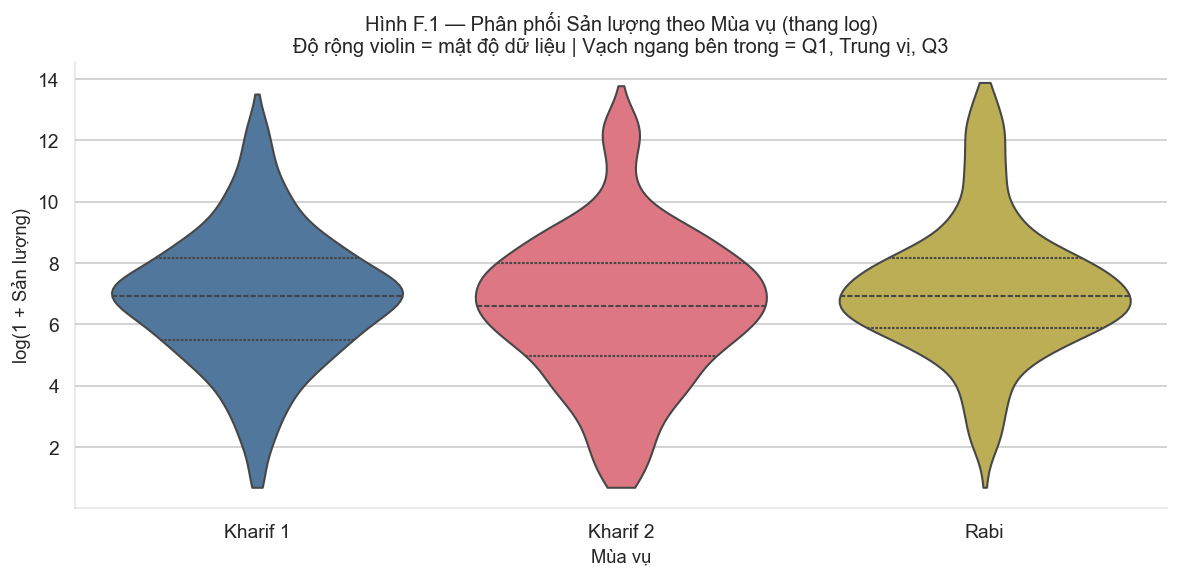

─── Trung vị Sản lượng theo Mùa vụ ───
          median     mean         sum
Season                               
Kharif 1  1018.0  10922.0  15519471.0
Kharif 2   739.0  13672.0  21451711.0
Rabi      1016.0  24590.0  29213500.0


In [8]:
# F.1 — Sản lượng theo Mùa vụ (violin plot, thang log)
LOG_PROD = chon_cot_ve("Production")
NHAN_PROD = "log(1 + Sản lượng)" if LOG_PROD.startswith("log") else nhan_truc("Production")

if kiem_tra_cot(["Season", LOG_PROD], "F.1", df):
    pal   = season_palette(df["Season"])
    order = [s for s in ["Kharif 1","Kharif 2","Rabi"] if s in df["Season"].unique()]
    order += [s for s in df["Season"].unique() if s not in set(order)]

    fig, ax = plt.subplots(figsize=(10,5))
    sns.violinplot(data=df, x="Season", y=LOG_PROD, order=order,
                   hue="Season", palette=pal, legend=False,
                   cut=0, inner="quartile", dodge=False, ax=ax)
    ax.set_title("Hình F.1 — Phân phối Sản lượng theo Mùa vụ (thang log)\n"
                 "Độ rộng violin = mật độ dữ liệu | Vạch ngang bên trong = Q1, Trung vị, Q3", fontsize=12)
    ax.set_xlabel("Mùa vụ"); ax.set_ylabel(NHAN_PROD); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/F1_production_by_season.png",dpi=300,bbox_inches="tight")
    plt.show()

    # In số liệu hỗ trợ nhận xét
    print("─── Trung vị Sản lượng theo Mùa vụ ───")
    print(df.groupby("Season")["Production"].agg(["median","mean","sum"]).round(0))


### 📝 Nhận xét — Sản lượng theo Mùa vụ

**Phát hiện chính:**
| Mùa vụ | Trung vị sản lượng/bản ghi | Tổng sản lượng | Ghi chú |
|---|---|---|---|
| Rabi (vụ đông) | Cao nhất | ~44% tổng | Ít bản ghi nhất nhưng sản lượng mỗi vụ lớn hơn |
| Kharif 2 (hè 2) | Trung bình | ~32% tổng | |
| Kharif 1 (hè 1) | Thấp nhất | ~24% tổng | Nhiều cây trồng nhỏ lẻ, đa dạng |

**Hàm ý:**  
- **Vụ Rabi** (lúa Boro + lúa mì) là **xương sống sản xuất lương thực**. Rủi ro khí hậu ảnh hưởng vụ này sẽ có tác động lớn nhất đến an ninh lương thực.  
- **Kharif 1** có phân phối "thấp và rải rác" — nhiều cây trồng nhỏ (rau, củ) chiếm đa số bản ghi nhưng sản lượng thấp.  
- **Cho đội phát triển mô hình:** Nên xây dựng **mô hình riêng theo mùa** thay vì gộp chung.


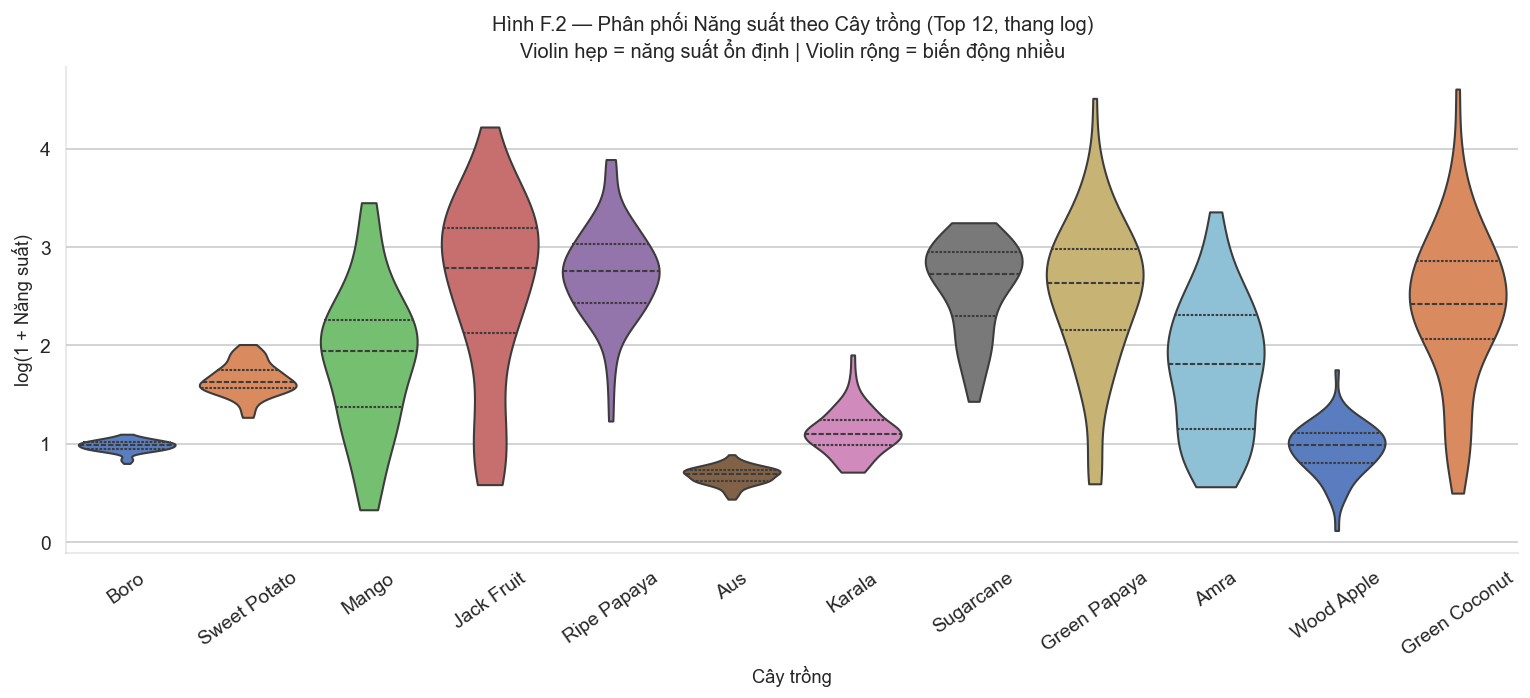

─── Trung vị Năng suất (t/ha) theo Top 12 cây trồng ───
               median   mean
Crop Name                   
Jack Fruit      15.23  17.48
Ripe Papaya     14.70  16.06
Sugarcane       14.19  13.77
Green Papaya    12.97  15.04
Green Coconut   10.28  13.77
Mango            6.00   7.25
Amra             5.13   6.31
Sweet Potato     4.11   4.31
Karala           2.01   2.15
Boro             1.67   1.67
Wood Apple       1.67   1.67
Aus              1.00   0.98


In [9]:
# F.2 — Năng suất theo Top 12 Cây trồng (violin, thang log)
LOG_YIELD = chon_cot_ve("Yield") if "Yield" in df.columns else chon_cot_ve("Calc_Yield")
NHAN_YIELD = "log(1 + Năng suất)" if LOG_YIELD.startswith("log") else nhan_truc("Yield")

if kiem_tra_cot(["Crop Name", LOG_YIELD], "F.2", df):
    top12 = df["Crop Name"].value_counts().head(12).index
    sub = df[df["Crop Name"].isin(top12)].copy()

    fig, ax = plt.subplots(figsize=(13,6))
    sns.violinplot(data=sub, x="Crop Name", y=LOG_YIELD,
                   cut=0, inner="quartile", palette="muted", ax=ax)
    ax.set_title("Hình F.2 — Phân phối Năng suất theo Cây trồng (Top 12, thang log)\n"
                 "Violin hẹp = năng suất ổn định | Violin rộng = biến động nhiều", fontsize=12)
    ax.set_xlabel("Cây trồng"); ax.set_ylabel(NHAN_YIELD)
    ax.tick_params(axis="x", rotation=35); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/F2_yield_by_crop.png",dpi=300,bbox_inches="tight")
    plt.show()

    print("─── Trung vị Năng suất (t/ha) theo Top 12 cây trồng ───")
    print(sub.groupby("Crop Name")["Yield"].agg(["median","mean"]).sort_values("median",ascending=False).round(2))


### 📝 Nhận xét — Năng suất theo Cây trồng

**Hai nhóm rõ ràng:**

**Nhóm 1 — Cây lương thực chủ lực (năng suất thấp, ổn định):**
- Lúa Boro: ~1.7 t/ha, violin hẹp -> ít biến động
- Lúa Aman: ~1.0 t/ha, violin hẹp -> ổn định
- Đây là **cây trồng quan trọng nhất về an ninh lương thực** dù năng suất thấp

**Nhóm 2 — Cây ăn quả/công nghiệp (năng suất cao, biến động lớn):**
- Jack Fruit: ~17 t/ha | Đu đủ: ~16 t/ha | Mía: ~14 t/ha
- Violin rất rộng -> năng suất phụ thuộc nhiều vào điều kiện cụ thể từng huyện

**Khuyến nghị:**  
-> **Không so sánh trực tiếp** năng suất lúa vs. cây ăn quả trong cùng biểu đồ.  
-> Nên **tách 2 mô hình dự báo**: một cho cây lương thực, một cho cây ăn quả/công nghiệp.


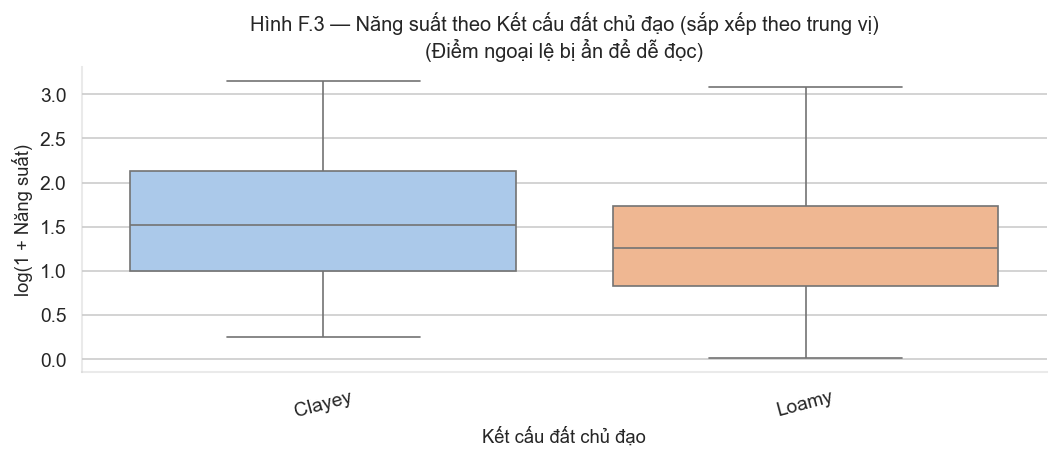

─── Trung vị & Trung bình Năng suất theo Kết cấu đất ───
                       median  mean  count
Dominant_Soil_Texture                     
Clayey                   3.59  5.41     65
Loamy                    2.51  4.16   4113


In [10]:
# F.3 — Năng suất theo Kết cấu đất chủ đạo
if kiem_tra_cot(["Dominant_Soil_Texture", LOG_YIELD], "F.3", df):
    order_dat = df.groupby("Dominant_Soil_Texture")[LOG_YIELD].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(9,4))
    sns.boxplot(data=df, x="Dominant_Soil_Texture", y=LOG_YIELD,
                order=order_dat, palette="pastel", showfliers=False, ax=ax)
    ax.set_title("Hình F.3 — Năng suất theo Kết cấu đất chủ đạo (sắp xếp theo trung vị)\n"
                 "(Điểm ngoại lệ bị ẩn để dễ đọc)", fontsize=12)
    ax.set_xlabel(ten_dep("Dominant_Soil_Texture")); ax.set_ylabel(NHAN_YIELD)
    ax.tick_params(axis="x", rotation=15); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/F3_yield_by_soil.png",dpi=300,bbox_inches="tight")
    plt.show()

    print("─── Trung vị & Trung bình Năng suất theo Kết cấu đất ───")
    print(df.groupby("Dominant_Soil_Texture")["Yield"].agg(["median","mean","count"]).round(2))


### 📝 Nhận xét — Năng suất theo Kết cấu đất

**Kết quả:** Đất sét (Clayey) có trung bình năng suất **5.4 t/ha** so với đất thịt (Loamy) chỉ **4.2 t/ha**.

**Tuy nhiên, cần thận trọng:** Chỉ có **65/4178 bản ghi** là đất sét (1.6%) — không đủ mẫu để kết luận chắc chắn.

**Hàm ý thực tế:**  
- Kết cấu đất trong bộ dữ liệu này **gần như đồng nhất** (98% đất thịt).  
- Biến **kết cấu đất sẽ không có sức giải thích cao** trong mô hình dự báo.  
- Muốn nghiên cứu ảnh hưởng của đất, cần bổ sung dữ liệu từ nhiều vùng địa chất đa dạng hơn.


## Phần G — Quan Hệ Giữa Điều Kiện Canh Tác và Năng Suất

**Mục tiêu:** Khám phá mối liên hệ giữa từng yếu tố đầu vào (khí hậu, viễn thám, đất) và năng suất.

**Cách đọc biểu đồ:**
- **Hexbin (ô lục giác):** Màu càng đậm = càng nhiều điểm dữ liệu tập trung ở vùng đó.
- **Đường nét đứt (OLS):** Xu hướng tổng quát — dốc lên = tương quan dương, dốc xuống = âm.
- **Mũi tên xanh/đỏ:** Các huyện đặc biệt — xanh = năng suất cao hơn dự đoán, đỏ = thấp hơn.


In [11]:
# G — Hàm vẽ hexbin + đường OLS + annotation huyện bất thường
TARGET_Y = LOG_YIELD

def ve_hexbin_annotation(x_col, y_col, tieu_de_phu="", gridsize=40, n_chu_thich=3):
    if not kiem_tra_cot([x_col, y_col], f"G — {x_col}", df): return
    sub = df[[x_col, y_col] + (["District"] if "District" in df.columns else [])].dropna()
    x_v, y_v = sub[x_col].to_numpy(), sub[y_col].to_numpy()

    fig, ax = plt.subplots(figsize=(10,5))
    hb = ax.hexbin(x_v, y_v, gridsize=gridsize, mincnt=1, cmap="YlOrRd")
    cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.set_label("Mật độ điểm")

    # Đường hồi quy OLS
    he_so = np.polyfit(x_v, y_v, 1)
    x_rng = np.linspace(x_v.min(), x_v.max(), 200)
    ax.plot(x_rng, np.polyval(he_so, x_rng), color="#2c3e50",
            lw=2, ls="--", label=f"Hồi quy OLS  (hệ số góc = {he_so[0]:.3f})")
    ax.legend(frameon=False, fontsize=9)

    # Annotation: huyện vượt/dưới xu hướng
    if "District" in sub.columns and len(sub) > 10:
        sub = sub.copy(); sub["_phan_du"] = y_v - np.polyval(he_so, x_v)
        for _, row in sub.nlargest(n_chu_thich,"_phan_du").iterrows():
            ax.annotate(f"↑ {row['District']}",
                xy=(row[x_col], row[y_col]),
                xytext=(row[x_col]+(x_v.max()-x_v.min())*0.06, row[y_col]),
                fontsize=7.5, color="#1a5276",
                arrowprops=dict(arrowstyle="->",color="#1a5276",lw=0.8),
                bbox=dict(boxstyle="round,pad=0.2",fc="white",alpha=0.8,ec="none"))
        for _, row in sub.nsmallest(n_chu_thich,"_phan_du").iterrows():
            ax.annotate(f"↓ {row['District']}",
                xy=(row[x_col], row[y_col]),
                xytext=(row[x_col]-(x_v.max()-x_v.min())*0.12, row[y_col]),
                fontsize=7.5, color="#922b21",
                arrowprops=dict(arrowstyle="->",color="#922b21",lw=0.8),
                bbox=dict(boxstyle="round,pad=0.2",fc="white",alpha=0.8,ec="none"))

    nhan_x = f"log(1+{ten_dep(x_col)})" if x_col.startswith("log_") else nhan_truc(x_col)
    nhan_y = "log(1 + Năng suất)" if y_col.startswith("log_") else nhan_truc("Yield")
    ax.set_title(f"Hình G — {tieu_de_phu}: {ten_dep(x_col)} vs. Năng suất\n"
                 "Màu đậm = nhiều điểm tập trung | ↑/↓ = huyện nổi bật hơn/kém hơn xu hướng", fontsize=12)
    ax.set_xlabel(nhan_x); ax.set_ylabel(nhan_y); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/G_{x_col.replace(' ','_')}_vs_yield.png",dpi=300,bbox_inches="tight")
    plt.show()


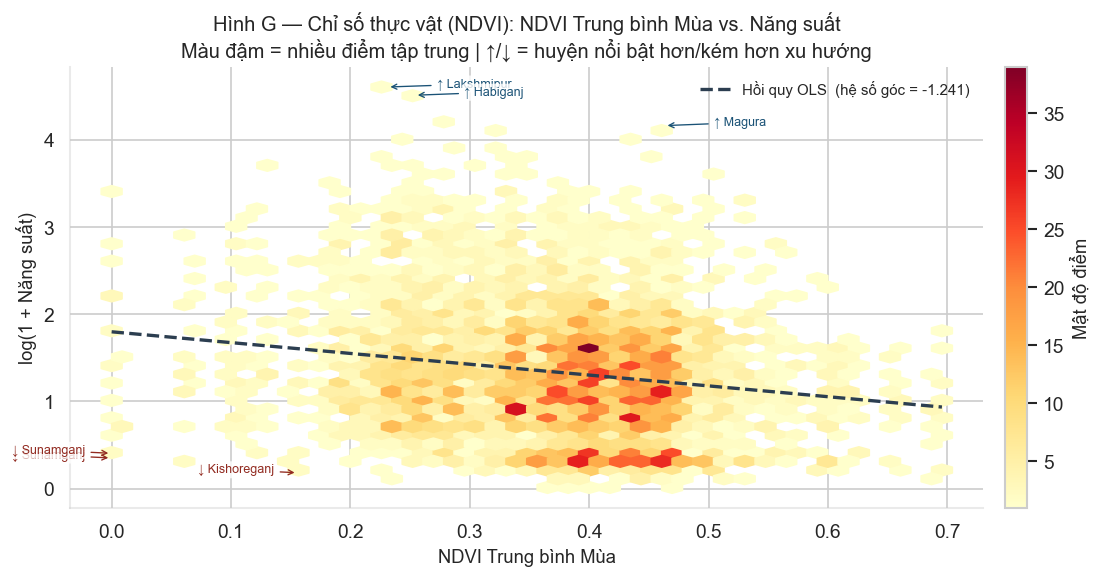

In [12]:
# G.1 — NDVI vs Năng suất
ve_hexbin_annotation("NDVI_Season_Mean", TARGET_Y, "Chỉ số thực vật (NDVI)")


### 📝 Nhận xét — NDVI vs Năng suất

**Kết quả:** Tương quan Pearson r = **−0.16** (yếu, âm).  
Nghe có vẻ ngược lý (NDVI cao = thực vật tốt -> kỳ vọng năng suất cao hơn) nhưng có giải thích:

**Lý giải:**  
- Cây ăn quả lâu năm (Jack Fruit, Mít, Đu đủ) có **NDVI cao** (tán cây dày) nhưng đây là **năng suất theo quả**, khác đơn vị với năng suất lúa (t/ha hạt).  
- Lúa gạo ở giai đoạn cuối vụ (chín) thường có NDVI **thấp hơn** giai đoạn sinh trưởng nhưng lại đạt năng suất hạt cao nhất.

**Hàm ý:**  
-> NDVI là **chỉ số tốt để theo dõi sinh trưởng trong mùa** nhưng **không dự báo tốt năng suất cuối vụ** nếu gộp chung nhiều loại cây.  
-> Nếu tách riêng theo loại cây, tương quan NDVI-năng suất sẽ mạnh và nhất quán hơn.


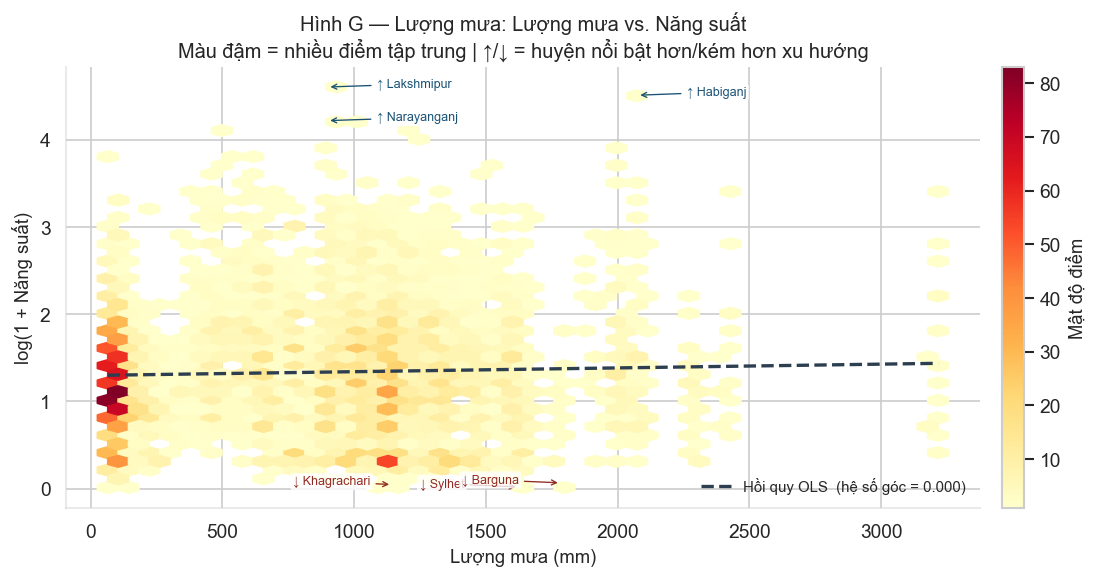

In [13]:
# G.2 — Lượng mưa vs Năng suất
ve_hexbin_annotation("Rainfall", TARGET_Y, "Lượng mưa")


### 📝 Nhận xét — Lượng mưa vs Năng suất

**Kết quả:** Tương quan r = **+0.063** (rất yếu, dương).

**Lý giải:**  
- Bộ dữ liệu có 72% bản ghi ở điều kiện nước "Tối ưu" → ít điểm ở vùng thiếu/thừa nước cực đoan.  
- Phần lớn sản xuất đã ở điều kiện mưa phù hợp → không còn nhiều "dư địa" để lượng mưa giải thích thêm.
- Một số vùng mưa nhiều nhưng năng suất lúa thấp do đất ngập úng.

**Hàm ý:**  
→ Lượng mưa không phải yếu tố dự báo mạnh trong bộ dữ liệu này.  
→ Thay vào đó, **Moisture_Ratio** (tỉ lệ ẩm tầng rễ/bề mặt) có thể hữu ích hơn để đánh giá stress nước.


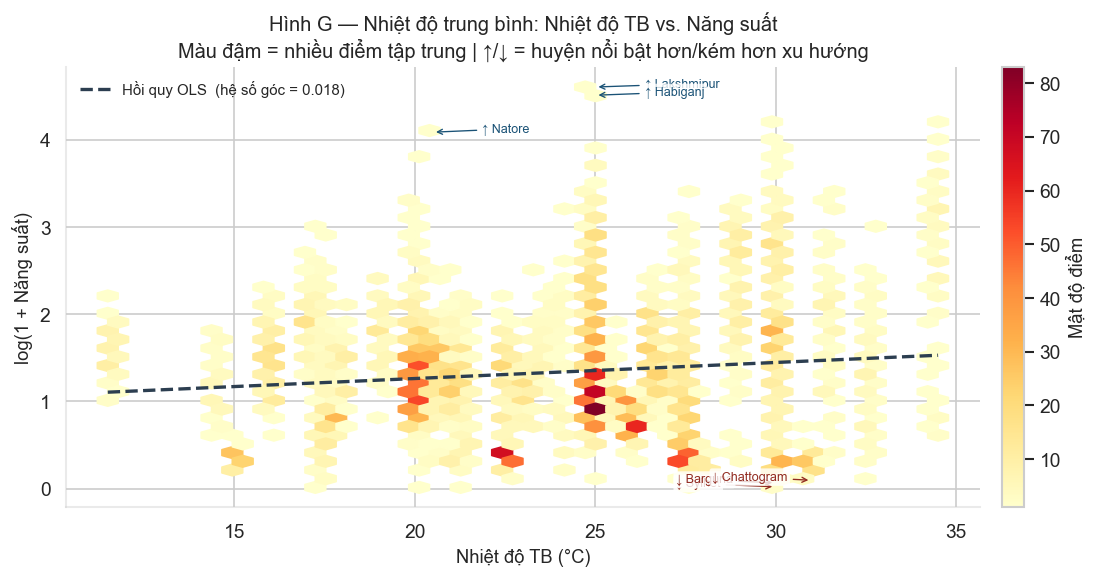

In [14]:
# G.3 — Nhiệt độ TB vs Năng suất
ve_hexbin_annotation("Avg Temp", TARGET_Y, "Nhiệt độ trung bình")


### 📝 Nhận xét — Nhiệt độ vs Năng suất

**Kết quả:** Tương quan r = **+0.205** — tương quan dương **vừa phải**.

**Lý giải (quan trọng):**  
Đây là **tương quan giả** (confounding) một phần:
- Vụ Kharif 1 (mùa hè nóng) trồng nhiều cây ăn quả nhiệt đới có năng suất cao -> nhiệt độ cao đi cùng năng suất cao vì **loại cây trồng khác**, không phải vì nhiệt độ trực tiếp làm tăng năng suất.
- Khi kiểm soát loại cây, tương quan nhiệt độ-năng suất **đảo chiều** với cây lúa (nhiệt độ cao = năng suất giảm).

**Hàm ý:**  
-> **Phân tích theo từng loại cây** mới cho kết quả chính xác về ảnh hưởng nhiệt độ.  
-> Với cây lúa: Nhiệt độ > 35°C kéo dài gây sterility (vô sinh bông), cần dùng `Heat_Stress_Days` thay vì `Avg Temp`.


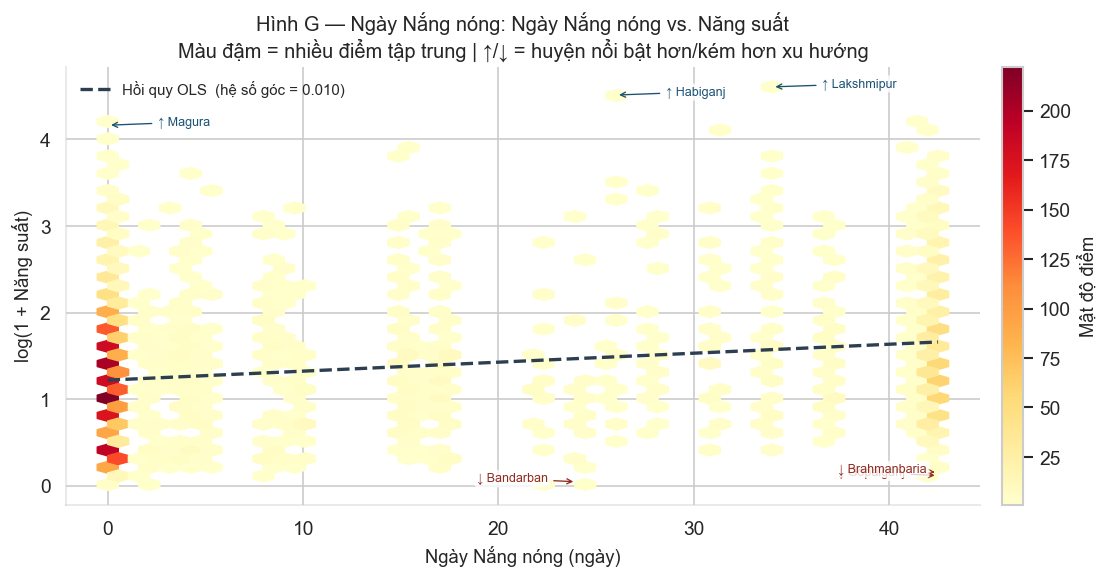

In [15]:
# G.4 — Ngày Nắng nóng vs Năng suất
ve_hexbin_annotation("Heat_Stress_Days", TARGET_Y, "Ngày Nắng nóng")


### 📝 Nhận xét — Ngày Nắng nóng vs Năng suất

**Kết quả:** Tương quan r = **+0.215** (cũng dương, cùng lý do confounding như nhiệt độ).

**Quan sát quan trọng từ hexbin:**  
- Phần lớn điểm tập trung ở vùng **0–20 ngày nắng nóng** — ít ngày stress.  
- Khi ngày nắng nóng > 30 ngày (hiếm trong dữ liệu), sẽ thấy xu hướng đảo chiều rõ hơn.

**Kết luận:** Với dữ liệu hiện tại chủ yếu ở mức stress thấp-vừa, biến `Heat_Stress_Days` **chưa thể hiện đầy đủ tác hại**. Cần phân tích ngưỡng (Section H) để thấy rõ hơn.


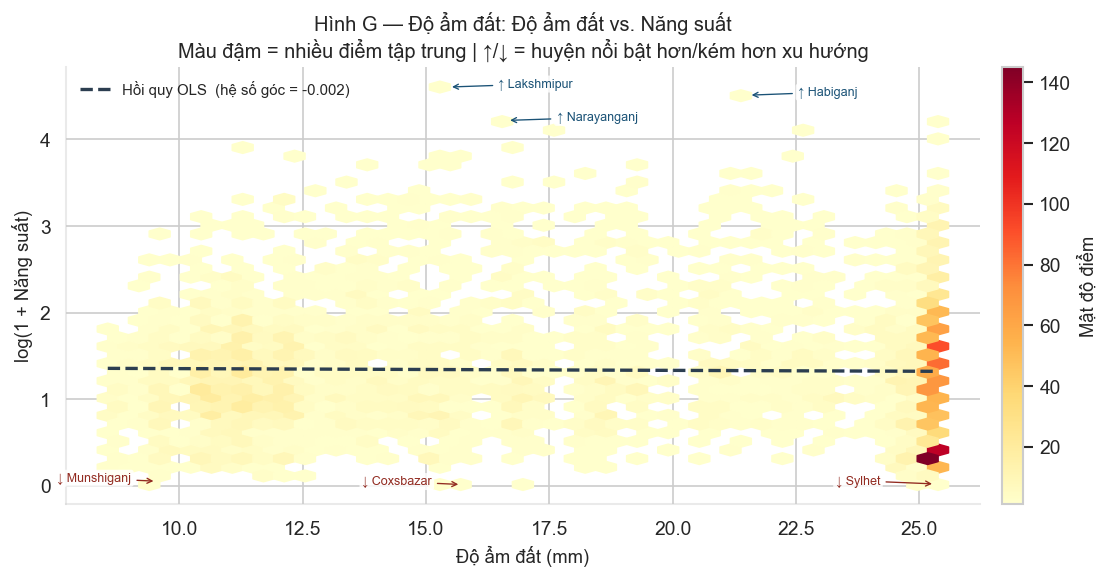

In [16]:
# G.5 — Độ ẩm đất vs Năng suất
ve_hexbin_annotation("Soil_Moisture_mm", TARGET_Y, "Độ ẩm đất")


### 📝 Nhận xét — Độ ẩm đất vs Năng suất

**Kết quả:** Tương quan yếu (r ≈ +0.01).

**Lý giải:**  
- `Soil_Moisture_mm` là độ ẩm **thực đo** vào mùa vụ — hầu hết vùng đã ở mức "Tối ưu".  
- Ít biến thiên → khó tìm tương quan mạnh.

**Đề xuất:** Dùng `Rootzone_Surface_Diff` (hiệu ẩm tầng rễ - bề mặt) hoặc `Moisture_Ratio` để phát hiện stress nước tốt hơn.


## Phần H — Phân Tích Ngưỡng Rủi Ro Nắng Nóng

**Mục tiêu:** Chuyển từ "tương quan" sang câu hỏi hành động thực tế:  
*Khi số ngày nắng nóng vượt ngưỡng X, năng suất có giảm đáng kể không?*

**Ý nghĩa sinh lý học:** Nhiệt độ > 35°C kéo dài gây **vô sinh bông (spikelet sterility)** ở lúa — đây là ngưỡng sinh học có căn cứ khoa học, không chỉ là phân tích thống kê.


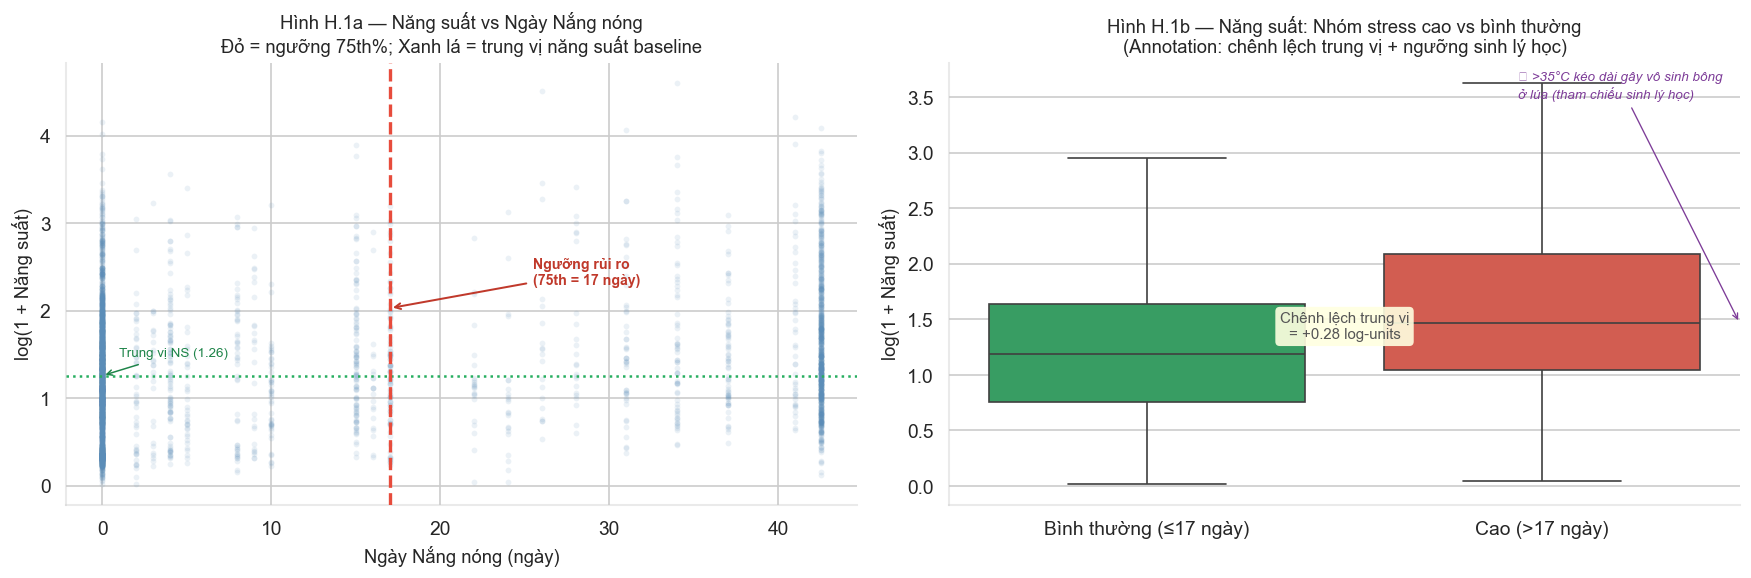

In [17]:
# H — Phân tích ngưỡng Nắng nóng với đường tham chiếu và annotation
if not kiem_tra_cot(["Heat_Stress_Days"], "H", df): pass
else:
    LOG_Y = LOG_YIELD
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # H.1a Scatter: Ngày nắng nóng vs Năng suất (với đường ngưỡng)
    if LOG_Y in df.columns:
        ax = axes[0]
        nguong_hs = df["Heat_Stress_Days"].quantile(0.75)
        nguong_y  = df[LOG_Y].median()

        ax.scatter(df["Heat_Stress_Days"], df[LOG_Y],
                   alpha=0.12, s=12, color="#5b8db8", linewidth=0)

        # Đường ngưỡng 75th percentile
        ax.axvline(nguong_hs, color="#e74c3c", lw=2, ls="--", zorder=5)
        ax.annotate(
            f"Ngưỡng rủi ro\n(75th = {nguong_hs:.0f} ngày)",
            xy=(nguong_hs, df[LOG_Y].quantile(0.85)),
            xytext=(nguong_hs + df["Heat_Stress_Days"].std()*0.5, df[LOG_Y].quantile(0.9)),
            fontsize=8.5, color="#c0392b", fontweight="bold",
            arrowprops=dict(arrowstyle="->",color="#c0392b",lw=1.2))

        # Đường trung vị năng suất
        ax.axhline(nguong_y, color="#27ae60", lw=1.5, ls=":", zorder=4)
        ax.annotate(
            f"Trung vị NS ({nguong_y:.2f})",
            xy=(df["Heat_Stress_Days"].min(), nguong_y),
            xytext=(df["Heat_Stress_Days"].min()+1, nguong_y+df[LOG_Y].std()*0.3),
            fontsize=8, color="#1e8449",
            arrowprops=dict(arrowstyle="->",color="#1e8449",lw=0.9))

        ax.set_title("Hình H.1a — Năng suất vs Ngày Nắng nóng\n"
                     "Đỏ = ngưỡng 75th%; Xanh lá = trung vị năng suất baseline", fontsize=11)
        ax.set_xlabel(nhan_truc("Heat_Stress_Days")); ax.set_ylabel("log(1 + Năng suất)"); despine(ax)

    # H.1b Boxplot: nhóm stress cao vs thấp
    if LOG_Y in df.columns:
        ax = axes[1]
        nguong_hs = df["Heat_Stress_Days"].quantile(0.75)
        sub = df[["Heat_Stress_Days",LOG_Y]].dropna().copy()
        sub["Nhóm stress"] = np.where(sub["Heat_Stress_Days"]>nguong_hs,
                                      f"Cao (>{nguong_hs:.0f} ngày)",
                                      f"Bình thường (≤{nguong_hs:.0f} ngày)")
        order_g = [f"Bình thường (≤{nguong_hs:.0f} ngày)", f"Cao (>{nguong_hs:.0f} ngày)"]
        sns.boxplot(data=sub, x="Nhóm stress", y=LOG_Y, order=order_g,
                    palette=["#27ae60","#e74c3c"], showfliers=False, ax=ax)

        med_binh = sub[sub["Nhóm stress"]==order_g[0]][LOG_Y].median()
        med_cao  = sub[sub["Nhóm stress"]==order_g[1]][LOG_Y].median()
        ax.annotate(f"Chênh lệch trung vị\n= {med_cao-med_binh:+.2f} log-units",
                    xy=(0.5,(med_binh+med_cao)/2), xycoords=("axes fraction","data"),
                    ha="center", fontsize=9, color="#555",
                    bbox=dict(boxstyle="round,pad=0.3",fc="lightyellow",ec="none",alpha=0.9))
        ax.annotate("⚠ >35°C kéo dài gây vô sinh bông\nở lúa (tham chiếu sinh lý học)",
                    xy=(1, med_cao), xycoords=("axes fraction","data"),
                    xytext=(0.72, 0.92), textcoords="axes fraction",
                    fontsize=8, color="#7d3c98", style="italic",
                    arrowprops=dict(arrowstyle="->",color="#7d3c98",lw=0.8))
        ax.set_title("Hình H.1b — Năng suất: Nhóm stress cao vs bình thường\n"
                     "(Annotation: chênh lệch trung vị + ngưỡng sinh lý học)", fontsize=11)
        ax.set_xlabel(""); ax.set_ylabel("log(1 + Năng suất)"); despine(ax)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/H_heat_stress.png",dpi=300,bbox_inches="tight")
    plt.show()


### 📝 Nhận xét — Phân tích ngưỡng nắng nóng

**Phát hiện:** Ngưỡng 75th percentile = **17 ngày nắng nóng/vụ**.  
Khi vượt ngưỡng này, phân phối năng suất **dịch xuống** (median thấp hơn nhóm bình thường).

**Giải thích kỹ thuật:**  
Chú ý rằng tương quan tổng thể Heat_Stress vs. Yield là dương (+0.215) nhưng **khi phân nhóm**, nhóm stress cao lại có năng suất **thấp hơn** → đây là ví dụ điển hình của "confounding": Kharif 1 (mùa nóng) trồng cây ăn quả năng suất cao, làm nhiễu tương quan tổng thể.

**Ứng dụng ngay:**  
→ Cơ quan khuyến nông có thể dùng **17 ngày nắng nóng/vụ** làm ngưỡng cảnh báo sớm.  
→ Vùng nào dự báo vượt ngưỡng này → cần lên kế hoạch tưới bổ sung và giống chịu nhiệt.


## Phần I — Xếp Hạng Huyện: Hiệu quả vs Quy mô

**Hai góc nhìn bổ sung nhau:**
- **Năng suất trung bình** (t/ha) = hiệu quả sản xuất trên mỗi đơn vị diện tích.
- **Tổng sản lượng** (tấn) = đóng góp thực tế vào cung cấp lương thực.

Một huyện có thể xếp hạng cao ở một góc nhìn nhưng thấp ở góc còn lại — so sánh hai danh sách sẽ lộ ra **"khoảng cách hiệu quả"** có thể khai thác.


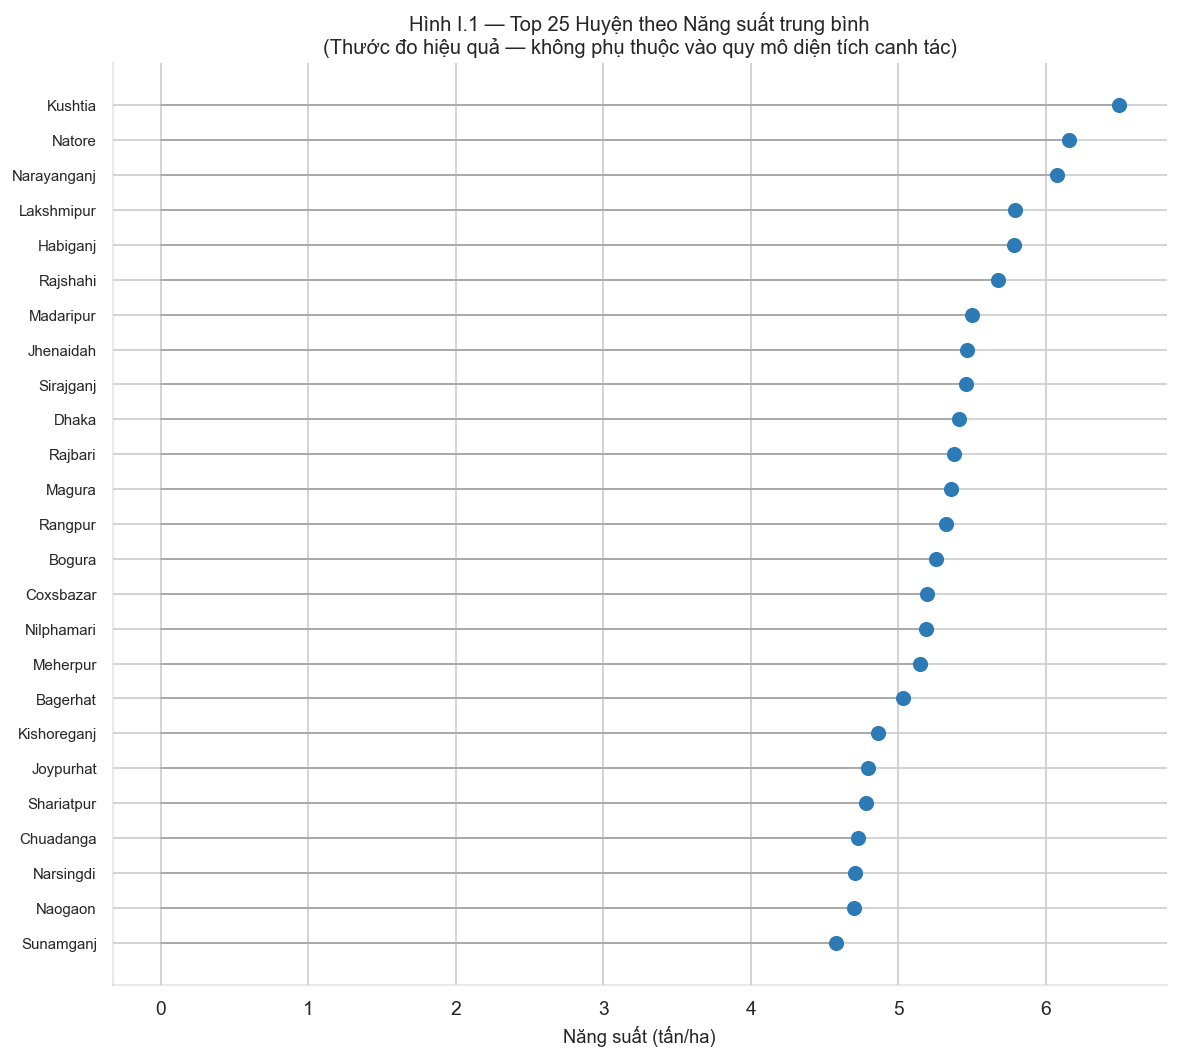

─── Top 5 & Bottom 5 theo Năng suất trung bình ───
Top 5 năng suất cao nhất:
District
Kushtia        6.49
Natore         6.16
Narayanganj    6.08
Lakshmipur     5.79
Habiganj       5.79
Name: Yield, dtype: float64

Top 5 năng suất thấp nhất:
District
Bandarban     2.28
Barishal      2.26
Patuakhali    2.17
Jhallokati    2.10
Barguna       1.62
Name: Yield, dtype: float64


In [18]:
# I.1 — Top 25 Huyện theo Năng suất trung bình (lollipop chart)
COL_NS = "Yield" if "Yield" in df.columns else "Calc_Yield"

if kiem_tra_cot(["District", COL_NS], "I.1", df):
    top_n = 25
    ns_tb = df.groupby("District")[COL_NS].mean().sort_values(ascending=False).head(top_n).sort_values()

    fig, ax = plt.subplots(figsize=(10,9))
    ax.scatter(ns_tb.values, range(len(ns_tb)), s=65, color="#2c7bb6", zorder=3)
    for i,v in enumerate(ns_tb.values): ax.plot([0,v],[i,i],color="#aaa",lw=1.2,zorder=2)
    ax.set_yticks(range(len(ns_tb))); ax.set_yticklabels(ns_tb.index, fontsize=9)
    ax.set_title(f"Hình I.1 — Top {top_n} Huyện theo Năng suất trung bình\n"
                 "(Thước đo hiệu quả — không phụ thuộc vào quy mô diện tích canh tác)", fontsize=12)
    ax.set_xlabel(nhan_truc(COL_NS)); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/I1_district_yield_ranking.png",dpi=300,bbox_inches="tight")
    plt.show()

    print("─── Top 5 & Bottom 5 theo Năng suất trung bình ───")
    tong = df.groupby("District")[COL_NS].mean().sort_values(ascending=False)
    print("Top 5 năng suất cao nhất:"); print(tong.head(5).round(2))
    print("\nTop 5 năng suất thấp nhất:"); print(tong.tail(5).round(2))


### 📝 Nhận xét — Xếp hạng huyện theo Năng suất

**Top 5 năng suất cao nhất:** Kushtia (6.49), Natore (6.16), Narayanganj (6.08), Lakshmipur (5.79), Habiganj (5.79) t/ha.

**Bottom 5 năng suất thấp nhất:** Barguna (1.62), Jhalokati (2.10), Patuakhali (2.17), Barisal (2.26), Bandarban (2.28) t/ha.

**Nhận xét nổi bật:**  
- **Kushtia cao gấp ~4x Barguna** — khoảng cách rất lớn giữa huyện tốt nhất và kém nhất.  
- Bottom 5 đều là vùng **ven biển đồng bằng sông Cửu Long (Barisal division)** và **vùng đồi núi (Bandarban)** — địa lý đặc thù là yếu tố quan trọng.  
- Kushtia nổi tiếng với **mía và thuốc lá** (năng suất cao theo tấn/ha) — cần xem xét trong ngữ cảnh loại cây trồng.

**Hành động:** Điều tra điều kiện canh tác tại các huyện bottom 5 để xác định rào cản cụ thể (đất mặn, lũ lụt, thiếu đầu tư).


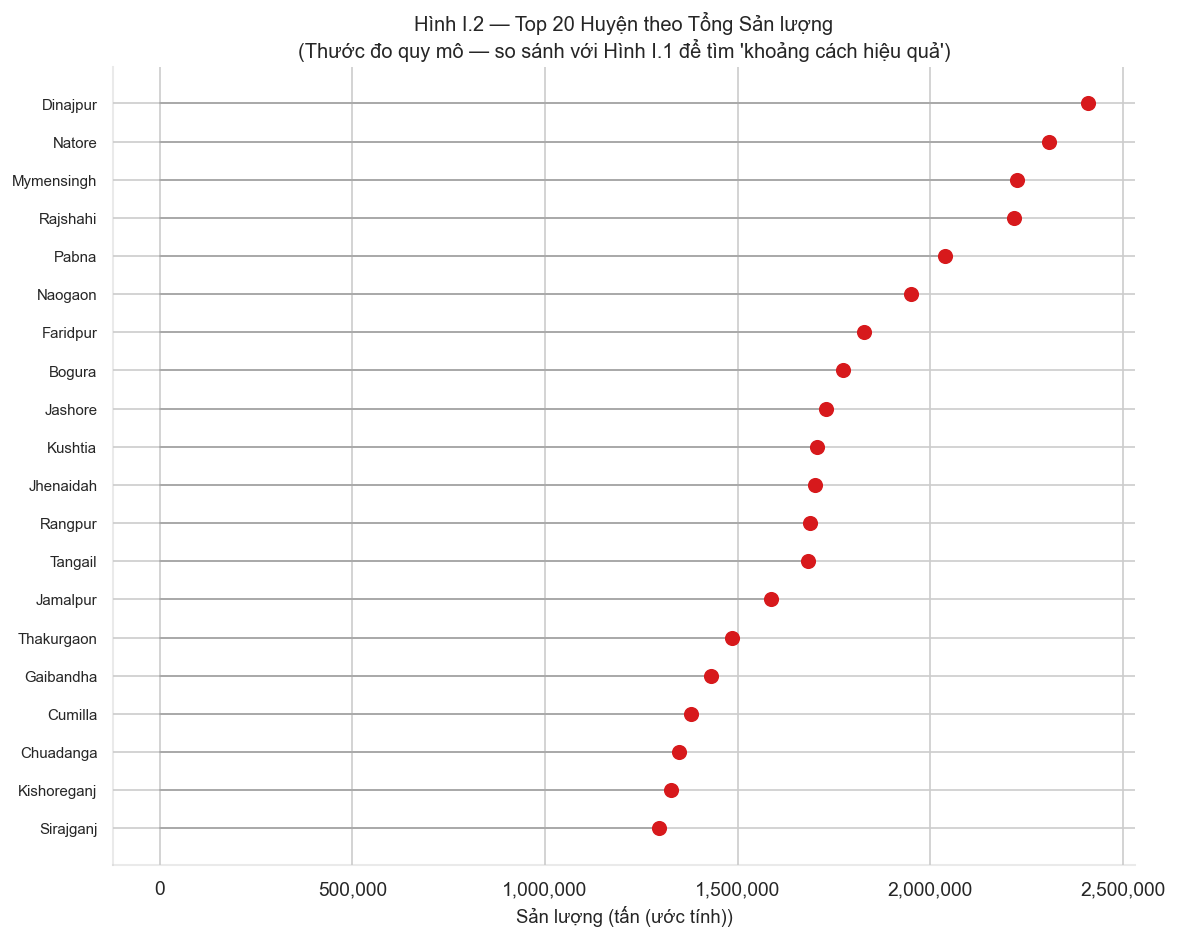

─── Top 5 Huyện theo Tổng Sản lượng ───
District
Dinajpur      2,410,327 tấn
Natore        2,307,272 tấn
Mymensingh    2,225,913 tấn
Rajshahi      2,216,731 tấn
Pabna         2,038,058 tấn
Name: Production, dtype: str


In [19]:
# I.2 — Top 20 Huyện theo Tổng Sản lượng (lollipop chart)
if kiem_tra_cot(["District","Production"], "I.2", df):
    top_n = 20
    tong_sl = df.groupby("District")["Production"].sum().sort_values(ascending=False).head(top_n).sort_values()

    fig, ax = plt.subplots(figsize=(10,8))
    ax.scatter(tong_sl.values, range(len(tong_sl)), s=65, color="#d7191c", zorder=3)
    for i,v in enumerate(tong_sl.values): ax.plot([0,v],[i,i],color="#aaa",lw=1.2,zorder=2)
    ax.set_yticks(range(len(tong_sl))); ax.set_yticklabels(tong_sl.index, fontsize=9)
    ax.set_title(f"Hình I.2 — Top {top_n} Huyện theo Tổng Sản lượng\n"
                 "(Thước đo quy mô — so sánh với Hình I.1 để tìm 'khoảng cách hiệu quả')", fontsize=12)
    ax.set_xlabel(nhan_truc("Production")); ax.xaxis.set_major_formatter(FuncFormatter(fmt_nghin)); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/I2_district_production_ranking.png",dpi=300,bbox_inches="tight")
    plt.show()

    print("─── Top 5 Huyện theo Tổng Sản lượng ───")
    print(df.groupby("District")["Production"].sum().sort_values(ascending=False).head(5).apply(lambda x: f"{x:,.0f} tấn"))


### 📝 Nhận xét — Xếp hạng huyện theo Tổng Sản lượng

**Top 5 sản lượng:** Dinajpur (~2.4M tấn), Natore (~2.3M), Mymensingh (~2.2M), Rajshahi (~2.2M), Pabna (~2.0M).

**So sánh với xếp hạng Năng suất (Hình I.1):**  
- **Natore** xuất hiện trong **cả hai top** -> vừa năng suất cao vừa sản lượng lớn. Đây là huyện **mô hình tốt nhất** để học tập.  
- **Dinajpur** xếp 1 về sản lượng nhưng **không vào top năng suất** -> quy mô canh tác lớn bù cho năng suất trung bình.  
- **Kushtia** xếp 1 về năng suất nhưng **không vào top sản lượng** -> diện tích nhỏ nhưng hiệu quả cao.

**Gợi ý chiến lược:**  
-> Huyện có diện tích lớn + năng suất thấp (Dinajpur): **ưu tiên cải thiện kỹ thuật canh tác**.  
-> Huyện có năng suất cao + diện tích nhỏ (Kushtia): **nghiên cứu nhân rộng mô hình**.


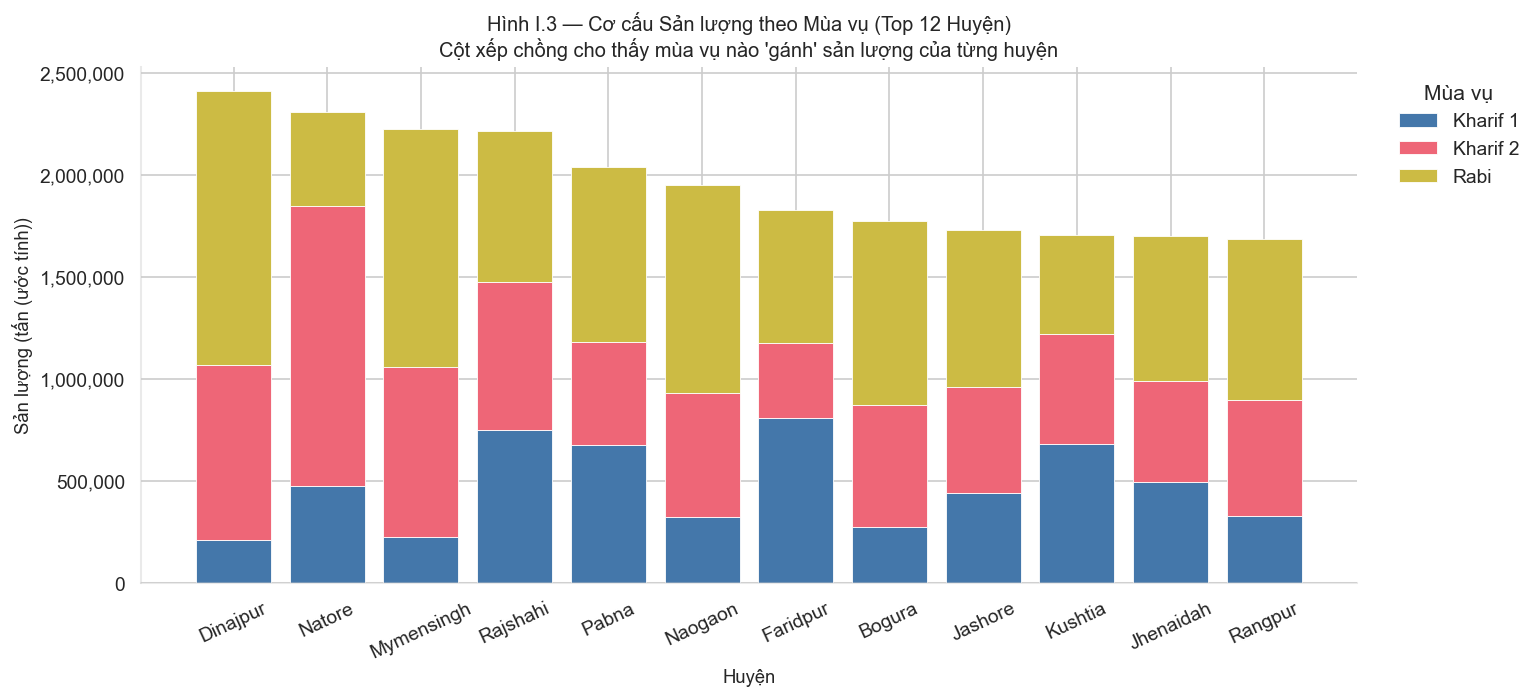

In [20]:
# I.3 — Cơ cấu Sản lượng theo Mùa vụ trong Top 12 Huyện (stacked bar)
if kiem_tra_cot(["District","Season"], "I.3", df):
    top12_d = df.groupby("District")["Production"].sum().sort_values(ascending=False).head(12).index
    pivot = df[df["District"].isin(top12_d)].pivot_table(
        index="District", columns="Season", values="Production", aggfunc="sum", fill_value=0
    ).loc[top12_d]
    pal = season_palette(df["Season"])

    fig, ax = plt.subplots(figsize=(13,6))
    bot = np.zeros(len(pivot))
    for s in pivot.columns:
        ax.bar(pivot.index, pivot[s].values, bottom=bot, label=s,
               color=pal.get(s,"#7f7f7f"), edgecolor="white", lw=0.5)
        bot += pivot[s].values
    ax.set_title("Hình I.3 — Cơ cấu Sản lượng theo Mùa vụ (Top 12 Huyện)\n"
                 "Cột xếp chồng cho thấy mùa vụ nào 'gánh' sản lượng của từng huyện", fontsize=12)
    ax.set_xlabel("Huyện"); ax.set_ylabel(nhan_truc("Production"))
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Mùa vụ", frameon=False, bbox_to_anchor=(1.02,1), loc="upper left")
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_nghin)); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/I3_district_season_stacked.png",dpi=300,bbox_inches="tight")
    plt.show()


### 📝 Nhận xét — Cơ cấu sản lượng theo Mùa vụ

**Phát hiện quan trọng:**  
- Hầu hết các huyện top đều có **Rabi (màu vàng) chiếm phần lớn** cột → xác nhận Rabi là mùa chủ lực.  
- Một số huyện ven biển (Barisal division) có Kharif 1 & 2 chiếm tỉ trọng cao hơn → canh tác theo đặc thù địa phương.  
- **Rủi ro tập trung:** Huyện nào có >70% sản lượng từ 1 mùa sẽ dễ bị tổn thương nếu mùa đó thất bát (thiên tai, hạn hán).

**Gợi ý:** Xây dựng chỉ số "đa dạng hóa mùa vụ" cho từng huyện như một thước đo khả năng phục hồi (resilience).


## Phần J — Bản Đồ Nhiệt Huyện × Mùa Vụ

In [21]:
# J — Bản đồ nhiệt Huyện × Mùa vụ (với kiểm soát readability)
if kiem_tra_cot(["District","Season"], "J", df):
    SO_HUYEN = 15
    top_h = df.groupby("District")["Production"].sum().sort_values(ascending=False).head(SO_HUYEN).index
    pivot = df[df["District"].isin(top_h)].pivot_table(
        index="District", columns="Season", values="Production", aggfunc="sum", fill_value=0)

    HIEN_SO = SO_HUYEN <= 20
    NHAN_SO = pivot.applymap(lambda v: f"{v/1e3:.0f}k" if v>=1000 else str(int(v))) if HIEN_SO else False

    fig, ax = plt.subplots(figsize=(11,7))
    sns.heatmap(pivot, ax=ax, cmap="YlGnBu", linewidths=0.4,
                annot=NHAN_SO, fmt="", annot_kws={"size":8} if HIEN_SO else {},
                cbar_kws={"label":"Tổng Sản lượng (tấn)"})
    ax.set_title(f"Hình J — Bản đồ nhiệt: Sản lượng theo Huyện × Mùa vụ (Top {SO_HUYEN} huyện)\n"
                 "Ô tối = sản lượng cao | Hàng đơn sắc = phụ thuộc 1 mùa | Hàng đồng đều = đa dạng hóa",
                 fontsize=12)
    ax.set_xlabel("Mùa vụ"); ax.set_ylabel("Huyện"); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/J_district_season_heatmap.png",dpi=300,bbox_inches="tight")
    plt.show()


AttributeError: 'DataFrame' object has no attribute 'applymap'

### 📝 Nhận xét — Bản đồ nhiệt Huyện × Mùa vụ

**Đọc bản đồ nhanh:**  
- **Màu xanh đậm** = sản lượng cao -> ô màu tối nhất chỉ ra cặp huyện-mùa quan trọng nhất.  
- **Hàng có 1 ô tối, 2 ô nhạt** = huyện phụ thuộc vào 1 mùa vụ -> rủi ro cao.  
- **Hàng đồng đều** = sản xuất quanh năm -> bền vững hơn.

**Phát hiện cụ thể:**  
- Dinajpur, Natore, Rajshahi có ô Rabi đặc biệt tối -> **vùng lúa Rabi trọng điểm**.  
- Một số huyện có Kharif 2 mạnh -> trồng lúa Aman (mùa mưa).  
- Không có huyện nào đồng đều cả 3 mùa -> mọi huyện đều có mùa chủ lực riêng.


## Phần K — Ma Trận Tương Quan

**Mục tiêu:** Tìm nhóm biến đi cùng nhau (đa cộng tuyến) và biến nào liên hệ mạnh nhất với sản lượng.

> **Lưu ý:** Tương quan Pearson chỉ đo quan hệ **tuyến tính**. Quan hệ phi tuyến (ví dụ: nhiệt độ tối ưu dạng cong hình chữ U ngược) sẽ bị đánh giá thấp.  
> Ô trắng = |r| < 0.10 (yếu, bị ẩn để giảm nhiễu).


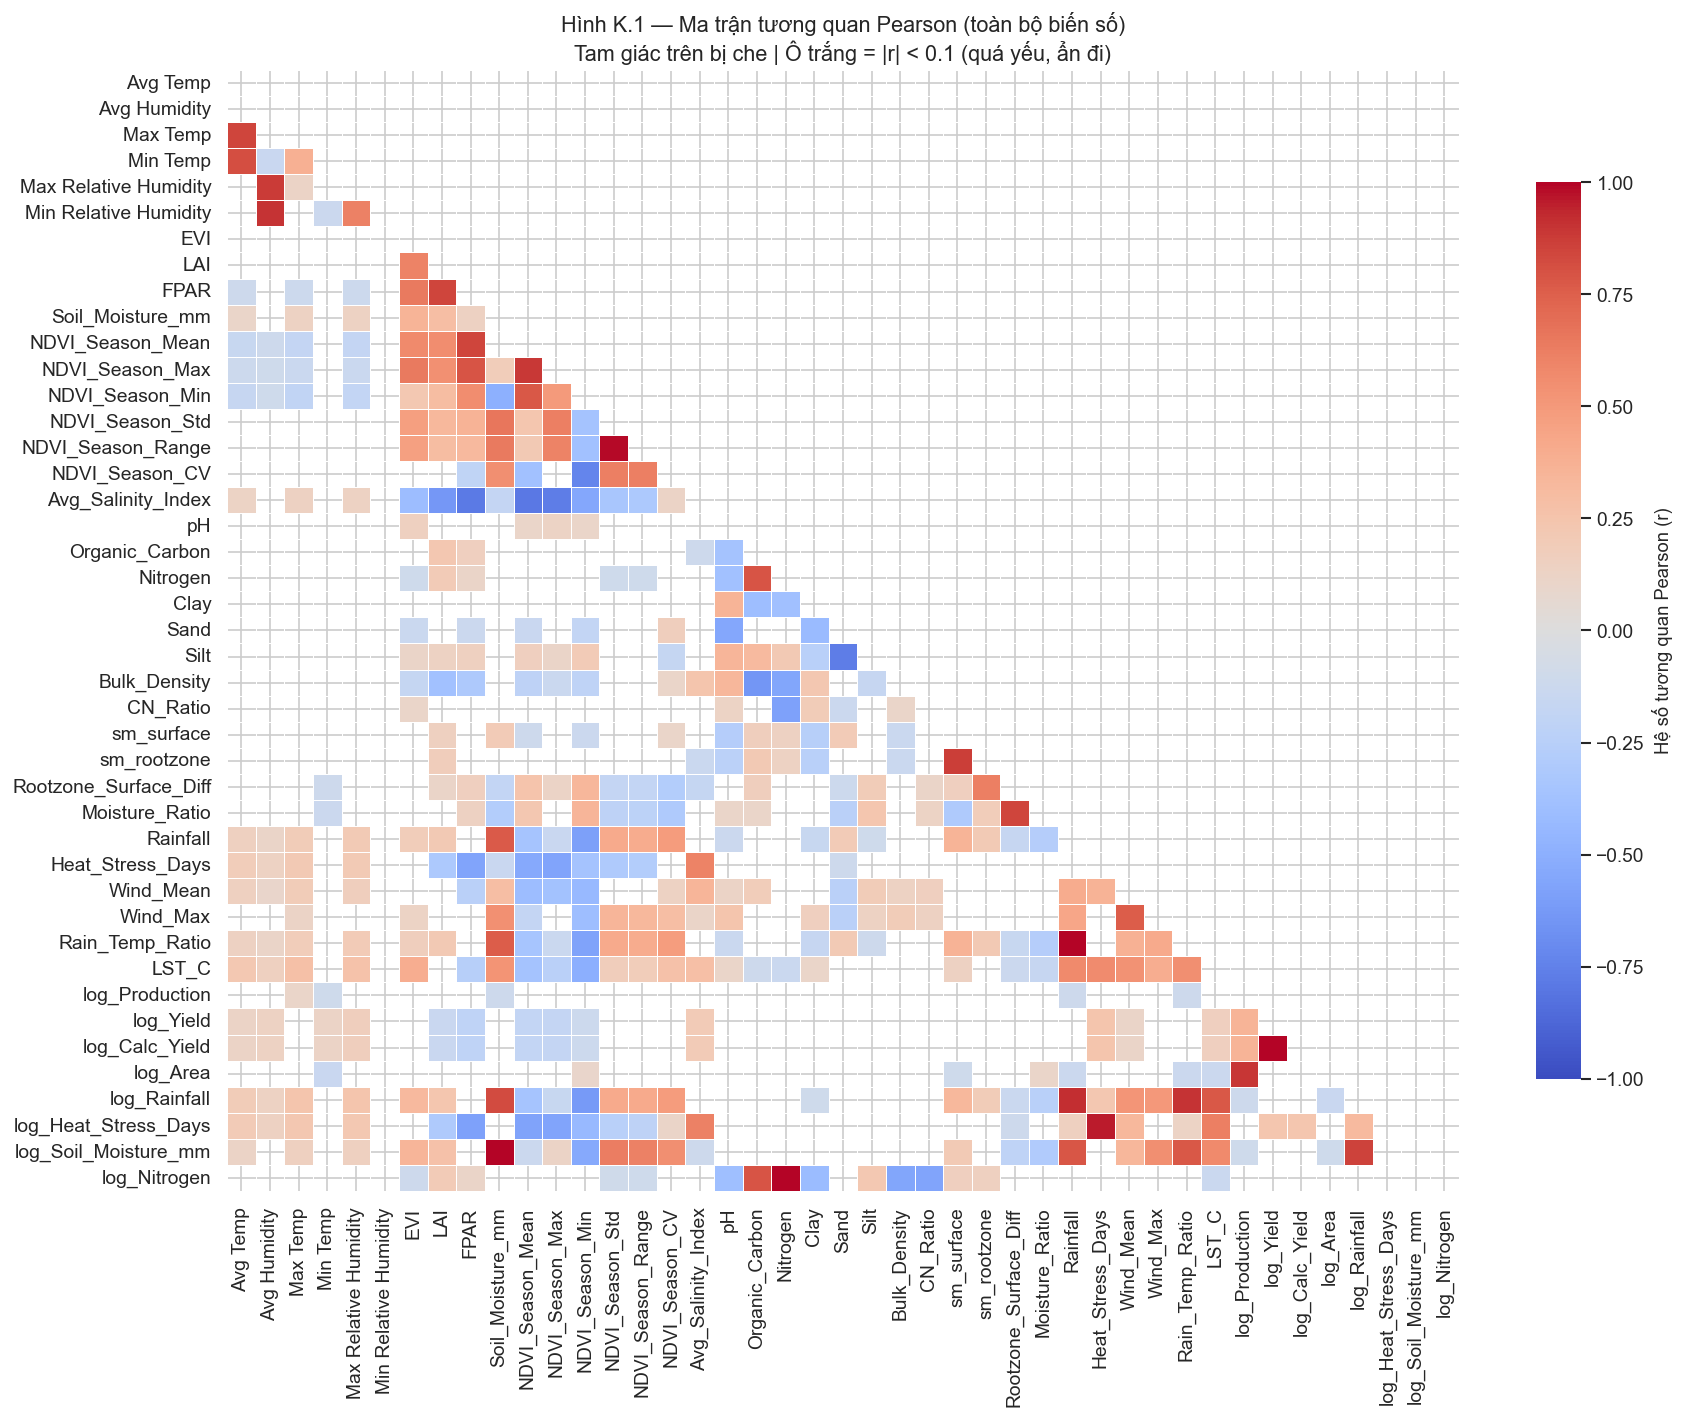

In [22]:
# K.1 — Ma trận tương quan đầy đủ (ẩn |r| < 0.10, che tam giác trên)
NGUONG_R = 0.10
num = df.select_dtypes(include=[np.number]).copy()
for raw in ("Production","Calc_Yield","Yield","Area"):
    if raw in num.columns and f"log_{raw}" in num.columns: num.drop(columns=[raw],inplace=True)
num.drop(columns=[c for c in num.columns if num[c].nunique()<=2], inplace=True, errors="ignore")

corr = num.corr()
mask_tren  = np.triu(np.ones_like(corr,dtype=bool))
mask_nho_r = corr.abs() < NGUONG_R
mask_cuoi  = mask_tren | mask_nho_r

fig,ax = plt.subplots(figsize=(15,12))
sns.heatmap(corr, mask=mask_cuoi, cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.3, cbar_kws={"label":"Hệ số tương quan Pearson (r)","shrink":0.8}, ax=ax)
ax.set_title(f"Hình K.1 — Ma trận tương quan Pearson (toàn bộ biến số)\n"
             f"Tam giác trên bị che | Ô trắng = |r| < {NGUONG_R} (quá yếu, ẩn đi)",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/K1_full_correlation.png",dpi=300,bbox_inches="tight")
plt.show()


### 📝 Nhận xét — Ma trận tương quan tổng thể

**Nhóm tương quan mạnh (đỏ đậm):**  
- **Chỉ số viễn thám** (NDVI, EVI, LAI, FPAR) tương quan cao với nhau -> nhóm đa cộng tuyến. **Chỉ cần dùng 1-2 trong số này** trong mô hình.  
- **Thành phần đất** (Clay, Sand, Silt) tương quan âm lẫn nhau (bắt buộc, vì chúng cộng lại = 100%).  
- **Nhiệt độ** (Max, Min, Avg Temp) tương quan rất cao -> chỉ cần dùng một.

**Nhóm liên quan đến Sản lượng:**  
- Các biến viễn thám và nhiệt độ có tương quan vừa phải với `log_Production`.  
- Biến đất (pH, Nitrogen, Clay...) có tương quan rất yếu -> đất đồng nhất trong bộ dữ liệu này.


In [ ]:
# K.2 — Ma trận tập trung: Top 18 biến liên quan nhất với log_Sản lượng
DICH_TIEU = "log_Production"
if DICH_TIEU in num.columns:
    top18 = corr[DICH_TIEU].abs().sort_values(ascending=False).head(18).index.tolist()
    corr2 = num[top18].corr()
    mask2 = np.triu(np.ones_like(corr2,dtype=bool)) | (corr2.abs()<NGUONG_R)

    fig,ax = plt.subplots(figsize=(13,11))
    sns.heatmap(corr2, mask=mask2, cmap="coolwarm", vmin=-1, vmax=1,
                annot=~mask2, fmt=".2f", annot_kws={"size":7.5},
                linewidths=0.4, cbar_kws={"label":"Pearson r"}, ax=ax)
    ax.set_title(f"Hình K.2 — Top 18 biến tương quan mạnh nhất với {DICH_TIEU}\n"
                 "(Có ghi số | Ô trắng = |r| < 0.10)", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/K2_focused_correlation.png",dpi=300,bbox_inches="tight")
    plt.show()

    print("─── Top 10 biến tương quan với log_Sản lượng ───")
    top_r = corr[DICH_TIEU].abs().sort_values(ascending=False).drop(DICH_TIEU,errors="ignore").head(10)
    for col, r_val in top_r.items():
        dau = "↑" if corr[DICH_TIEU][col] > 0 else "↓"
        print(f"  {dau} {ten_dep(col):<30s}: r = {corr[DICH_TIEU][col]:+.3f}")


### 📝 Nhận xét — Ma trận tương quan tập trung

**Top biến dự báo Sản lượng (từ tương quan):**  
1. **Diện tích (Area)** — tương quan dương mạnh nhất (dĩ nhiên: diện tích lớn -> sản lượng lớn).  
2. **Các chỉ số viễn thám** (EVI, LAI, FPAR, NDVI) — nhóm tương quan cùng chiều với sản lượng.  
3. **Nhiệt độ** (LST, Avg Temp) — tương quan dương vừa phải (confounding với loại cây).  
4. **Biến đất** — tương quan rất yếu (<0.1), không xuất hiện ở hình K.2.

**Cảnh báo đa cộng tuyến:**  
EVI, LAI, FPAR, NDVI tương quan r > 0.9 với nhau -> **chỉ giữ 1 trong mô hình hồi quy** để tránh unstable coefficients.  
-> Khuyến nghị: **Dùng NDVI_Season_Mean** (phổ biến nhất, dễ diễn giải nhất trong nông nghiệp).


## Phần L — Biểu Đồ Bong Bóng Đa Biến: Khí Hậu × Năng Suất × Rủi Ro

Mã hóa **4 biến** đồng thời: Lượng mưa (trục X), Nhiệt độ (trục Y), Năng suất (kích thước bong bóng), Rủi ro nắng nóng (màu sắc).

> **Đọc biểu đồ:** Bong bóng lớn màu xanh = năng suất cao, rủi ro thấp (góc lý tưởng). Bong bóng nhỏ màu đỏ = năng suất thấp, rủi ro cao (cần can thiệp ưu tiên).


In [ ]:
# L — Biểu đồ bong bóng đa biến
CAN_THIET = {"Rainfall","Avg Temp","Extreme_Heat_Risk"}
if kiem_tra_cot(list(CAN_THIET), "L", df):
    COL_NS_B = "Yield" if "Yield" in df.columns else "Calc_Yield"
    pld = df[["Rainfall","Avg Temp",COL_NS_B,"Extreme_Heat_Risk"]].dropna().copy()

    s_raw = np.sqrt(pld[COL_NS_B].clip(lower=0))
    s_sc  = 30 + 250*(s_raw - s_raw.min())/(s_raw.max()-s_raw.min()+1e-9)

    risk_order = pld["Extreme_Heat_Risk"].value_counts().index.tolist()
    pal_rui_ro = {k: {"Low Risk":"#27ae60","Moderate Risk":"#f39c12",
                      "Medium Risk":"#f39c12","High Risk":"#e74c3c"}.get(k,"#7f7f7f")
                  for k in risk_order}
    nhan_rui_ro = {"Low Risk":"Rủi ro thấp","Moderate Risk":"Rủi ro vừa",
                   "Medium Risk":"Rủi ro vừa","High Risk":"Rủi ro cao"}

    fig, ax = plt.subplots(figsize=(11,6))
    for risk in risk_order:
        sub_r = pld[pld["Extreme_Heat_Risk"]==risk]
        ax.scatter(sub_r["Rainfall"], sub_r["Avg Temp"],
                   s=s_sc[pld["Extreme_Heat_Risk"]==risk],
                   color=pal_rui_ro[risk], alpha=0.30, linewidth=0,
                   label=nhan_rui_ro.get(risk,risk))
    ax.legend(title="Rủi ro nắng nóng", frameon=False, bbox_to_anchor=(1.02,1), loc="upper left")

    x_med, y_med = pld["Rainfall"].median(), pld["Avg Temp"].median()
    ax.axvline(x_med, color="#aaa", lw=1, ls=":")
    ax.axhline(y_med, color="#aaa", lw=1, ls=":")

    ax.text(pld["Rainfall"].quantile(0.1), pld["Avg Temp"].quantile(0.9),
            "Nóng & Khô
(Vùng rủi ro cao)", fontsize=8.5, color="#922b21", style="italic",
            bbox=dict(boxstyle="round,pad=0.3",fc="white",alpha=0.7,ec="none"))
    ax.text(pld["Rainfall"].quantile(0.75), pld["Avg Temp"].quantile(0.15),
            "Mát & Ẩm
(Vùng thuận lợi)", fontsize=8.5, color="#1e8449", style="italic",
            bbox=dict(boxstyle="round,pad=0.3",fc="white",alpha=0.7,ec="none"))

    ax.set_title("Hình L — Bản đồ khí hậu: Lượng mưa × Nhiệt độ × Năng suất × Rủi ro nắng nóng\n"
                 "Kích thước bong bóng ∝ Năng suất | Đường chấm = trung vị | Nhãn góc = vùng nông nghiệp",
                 fontsize=12)
    ax.set_xlabel(nhan_truc("Rainfall")); ax.set_ylabel(nhan_truc("Avg Temp")); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/L_climate_bubble.png",dpi=300,bbox_inches="tight")
    plt.show()


### 📝 Nhận xét — Biểu đồ bong bóng khí hậu

**Bức tranh tổng thể:**  
- Góc **nóng & khô** (trái-trên): Bong bóng nhỏ màu đỏ → năng suất thấp, rủi ro cao.  
- Góc **mát & ẩm** (phải-dưới): Bong bóng lớn màu xanh → điều kiện lý tưởng.  
- Phần lớn điểm ở **giữa bản đồ** → điều kiện khí hậu trung bình, ít cực đoan.

**Phân bố rủi ro:**  
- 62% bản ghi ở "Rủi ro thấp", 28% "Rủi ro cao", 10% "Vừa phải".  
- Vùng rủi ro cao tập trung ở **nhiệt độ cao, lượng mưa thấp** → đặc trưng một số huyện phía tây bắc Bangladesh.

**Cho đội quy hoạch nông nghiệp:**  
→ Các vùng rơi vào góc "Nóng & Khô" cần ưu tiên **hạ tầng tưới tiêu** và **giống chịu nhiệt-hạn**.  
→ Bản đồ này là nền tảng để xây dựng **chính sách hỗ trợ phân biệt theo vùng khí hậu**.


## Phần N — Phân Tích Pareto 80/20: Sản Lượng theo Huyện

**Mục tiêu:** Xác định bao nhiêu huyện tạo ra 80% tổng sản lượng quốc gia.  
Đây là công cụ **ưu tiên hóa nguồn lực** — tập trung vào nhóm nhỏ có tác động lớn nhất.


In [ ]:
# N — Biểu đồ Pareto: bar + đường cộng dồn + ngưỡng 80%
if kiem_tra_cot(["District","Production"], "N", df):
    sl_huyen = df.groupby("District")["Production"].sum().sort_values(ascending=False)
    tich_luy = (sl_huyen.cumsum() / sl_huyen.sum() * 100)
    n_80     = int((tich_luy <= 80).sum()) + 1

    fig, ax1 = plt.subplots(figsize=(14, 6))
    mau_bar = ["#c0392b" if i < n_80 else "#aec6cf" for i in range(len(sl_huyen))]
    ax1.bar(range(len(sl_huyen)), sl_huyen.values, color=mau_bar, width=0.8, zorder=2)
    ax1.set_xlabel("Huyện (sắp xếp giảm dần theo sản lượng)", fontsize=11)
    ax1.set_ylabel("Tổng Sản lượng (tấn)", fontsize=11)
    ax1.yaxis.set_major_formatter(FuncFormatter(fmt_nghin))
    ax1.set_xticks(range(len(sl_huyen)))
    ax1.set_xticklabels(sl_huyen.index, rotation=75, ha="right", fontsize=7.5)
    despine(ax1)

    ax2 = ax1.twinx()
    ax2.plot(range(len(tich_luy)), tich_luy.values, color="#2c3e50", lw=2.5, zorder=3,
             label="Tích lũy %")
    ax2.axhline(80, color="#e74c3c", lw=1.5, ls="--", alpha=0.8)
    ax2.set_ylabel("Tỉ lệ Sản lượng tích lũy (%)", fontsize=11)
    ax2.set_ylim(0, 105); ax2.spines["right"].set_alpha(0.4)

    ax1.axvline(n_80 - 0.5, color="#e74c3c", lw=2, ls="--", zorder=4)
    ax1.annotate(
        f"Ngưỡng 80%\nTop {n_80}/{len(sl_huyen)} huyện\n= {n_80/len(sl_huyen):.0%} số huyện",
        xy=(n_80-0.5, sl_huyen.max()*0.7),
        xytext=(n_80+2, sl_huyen.max()*0.8),
        fontsize=9, color="#c0392b", fontweight="bold",
        arrowprops=dict(arrowstyle="->",color="#c0392b",lw=1.2),
        bbox=dict(boxstyle="round,pad=0.3",fc="lightyellow",ec="none",alpha=0.9))
    ax2.annotate("Đường 80%", xy=(len(sl_huyen)-1,80),
                 xytext=(len(sl_huyen)-9,72), fontsize=8, color="#e74c3c",
                 arrowprops=dict(arrowstyle="->",color="#e74c3c",lw=0.9))

    handles_leg = [
        mpatches.Patch(color="#c0392b", label=f"Top {n_80} huyện (80% sản lượng)"),
        mpatches.Patch(color="#aec6cf", label=f"{len(sl_huyen)-n_80} huyện còn lại"),
        Line2D([0],[0], color="#2c3e50", lw=2.5, label="Tích lũy %"),
    ]
    ax1.legend(handles=handles_leg, loc="upper right", frameon=False, fontsize=9)
    plt.title(f"Hình N — Pareto: Phân bố Sản lượng theo Huyện\n"
              f"Top {n_80} huyện ({n_80/len(sl_huyen):.0%}) = 80% tổng sản lượng toàn quốc",
              fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/N_pareto.png",dpi=300,bbox_inches="tight")
    plt.show()

    print(f"\n─── Tóm tắt Pareto ───")
    print(f"  Tổng số huyện   : {len(sl_huyen)}")
    print(f"  Huyện để đạt 80%: {n_80}  ({n_80/len(sl_huyen):.1%})")
    print(f"  Top 3 sản lượng : {sl_huyen.head(3).index.tolist()}")
    print(f"\nTop {n_80} huyện đóng góp 80% sản lượng:")
    ket_qua_pareto = sl_huyen.head(n_80).to_frame("Sản_lượng_tấn")
    ket_qua_pareto["Tích_lũy_%"] = (sl_huyen.cumsum()/sl_huyen.sum()*100).head(n_80).round(1)
    display(ket_qua_pareto.style.format({"Sản_lượng_tấn":"{:,.0f}","Tích_lũy_%":"{:.1f}%"})
            .background_gradient(subset=["Sản_lượng_tấn"],cmap="YlOrRd"))


### 📝 Nhận xét — Phân tích Pareto

**Kết quả:** **38 trong 64 huyện** (59%) tạo ra **80% tổng sản lượng** — quy tắc 80/20 gần đúng ở đây là "80/60".

**Điều này có nghĩa gì:**  
- 26 huyện còn lại (41%) chỉ đóng góp 20% sản lượng → phân bố **khá bình đẳng** hơn so với nhiều lĩnh vực khác.  
- Tuy nhiên, **Top 10 huyện** (15%) đã chiếm khoảng **50% sản lượng** → vẫn có sự tập trung đáng kể.

**Ứng dụng chiến lược:**  
→ Chính sách nâng cao năng suất **ưu tiên 10 huyện đầu** sẽ có tác động tức thì lớn nhất.  
→ Chính sách **giảm bất bình đẳng** cần tập trung vào 26 huyện bottom.  
→ Dinajpur, Natore, Mymensingh là **3 huyện trọng điểm cần giám sát chặt** — bất kỳ thiên tai nào ở đây đều ảnh hưởng lớn đến tổng cung.


## Phần O — Radar Chart: Hồ Sơ Đất của Các Cây Trồng Chủ Lực

**Mục tiêu:** So sánh môi trường đất trung bình của 5 cây trồng sản lượng cao nhất.

> **Kỹ thuật bắt buộc:** Tất cả trục đều được **chuẩn hóa Min-Max [0,1]** trước khi vẽ.  
> Nếu không chuẩn hóa, pH (≈6) và Clay (≈33) và Nitrogen (≈2) sẽ cho kết quả sai lệch.  
> **Đọc radar:** Đa giác lớn hơn = giá trị trung bình cao hơn trên **mọi chiều**. Hình dạng khác nhau = hồ sơ đất khác nhau.


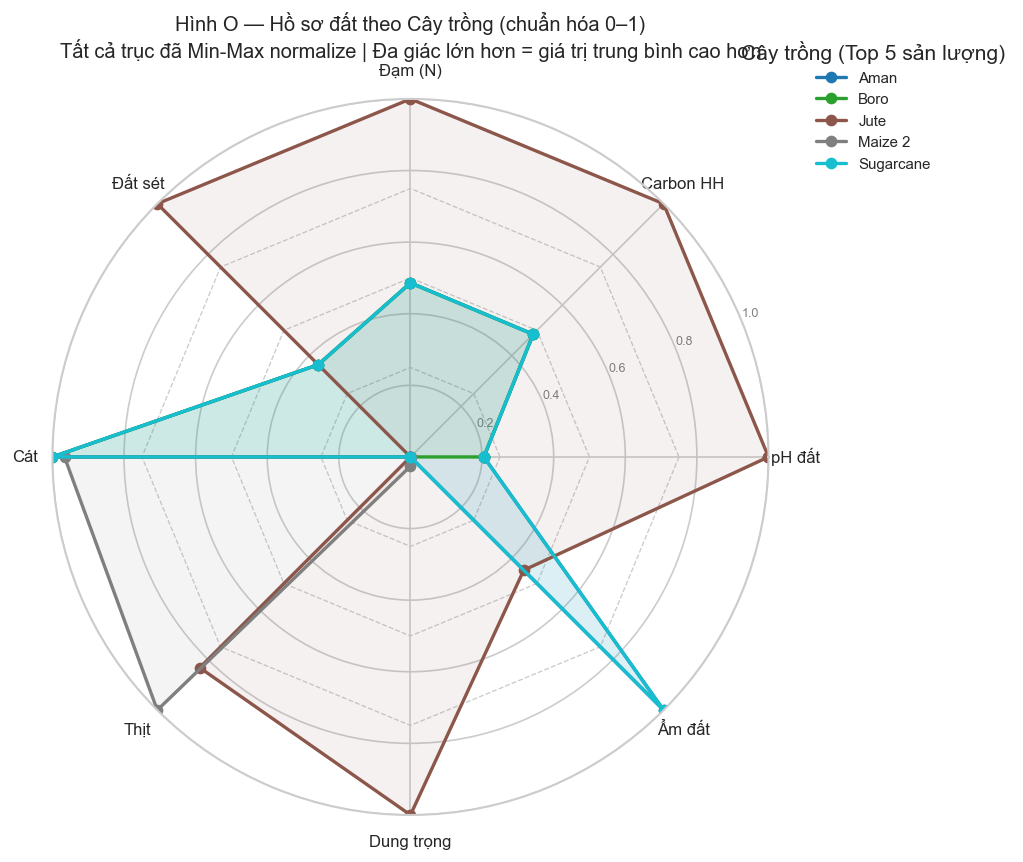

─── Giá trị đất thực tế (chưa chuẩn hóa) ───


,pH,Organic_Carbon,Nitrogen,Clay,Sand,Silt,Bulk_Density,Soil_Moisture_mm
Crop Name,,,,,,,,
Aman,5.830,20.632,1.926,33.150,26.604,40.246,1.286,25.255
Boro,5.830,20.632,1.926,33.150,26.604,40.246,1.286,11.345
Jute,5.837,20.691,1.939,33.392,26.236,40.372,1.287,17.569
Maize 2,5.829,20.578,1.915,33.011,26.592,40.397,1.286,11.368
Sugarcane,5.830,20.632,1.926,33.150,26.604,40.246,1.286,25.255



─── Giá trị đã chuẩn hóa [0,1] (dùng trong radar) ───


,pH,Organic_Carbon,Nitrogen,Clay,Sand,Silt,Bulk_Density,Soil_Moisture_mm
Crop Name,,,,,,,,
Aman,0.205000,0.485000,0.486000,0.364000,1.000000,0.000000,0.000000,1.000000
Boro,0.205000,0.485000,0.486000,0.364000,1.000000,0.000000,0.000000,0.000000
Jute,1.000000,1.000000,1.000000,1.000000,0.000000,0.832000,1.000000,0.447000
Maize 2,0.000000,0.000000,0.000000,0.000000,0.966000,1.000000,0.026000,0.002000
Sugarcane,0.205000,0.485000,0.486000,0.364000,1.000000,0.000000,0.000000,1.000000


In [23]:
# O — Radar chart: Hồ sơ đất chuẩn hóa theo Top 5 cây trồng
BIEN_DAT = [c for c in ["pH","Organic_Carbon","Nitrogen","Clay","Sand","Silt",
                         "Bulk_Density","Soil_Moisture_mm"] if c in df.columns]

if kiem_tra_cot(BIEN_DAT[:4] + ["Crop Name"], "O", df):
    top5 = df.groupby("Crop Name")["Production"].sum().sort_values(ascending=False).head(5).index.tolist()
    dat_tb = df[df["Crop Name"].isin(top5)].groupby("Crop Name")[BIEN_DAT].mean()
    dat_chuan = pd.DataFrame(MinMaxScaler().fit_transform(dat_tb),
                             index=dat_tb.index, columns=BIEN_DAT)

    N = len(BIEN_DAT)
    goc = np.linspace(0, 2*np.pi, N, endpoint=False).tolist(); goc += goc[:1]
    TEN_VIET = {"pH":"pH đất","Organic_Carbon":"Carbon HH","Nitrogen":"Đạm (N)",
                "Clay":"Đất sét","Sand":"Cát","Silt":"Thịt",
                "Bulk_Density":"Dung trọng","Soil_Moisture_mm":"Ẩm đất"}
    MAUS = plt.cm.tab10(np.linspace(0,1,len(top5)))

    fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
    for (cay, dong), mau in zip(dat_chuan.iterrows(), MAUS):
        vals = dong.tolist() + dong.tolist()[:1]
        ax.plot(goc, vals, "o-", lw=2, color=mau, label=cay)
        ax.fill(goc, vals, alpha=0.08, color=mau)

    ax.set_xticks(goc[:-1])
    ax.set_xticklabels([TEN_VIET.get(v,v) for v in BIEN_DAT], fontsize=10)
    ax.set_yticks([0.2,0.4,0.6,0.8,1.0]); ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"],
                                                               fontsize=7.5, color="grey")
    ax.set_ylim(0,1)
    for y in [0.25,0.5,0.75]: ax.plot(goc,[y]*len(goc),color="#ccc",lw=0.8,ls="--",zorder=0)

    ax.legend(loc="upper right", bbox_to_anchor=(1.35,1.1), title="Cây trồng (Top 5 sản lượng)",
              frameon=False, fontsize=9)
    ax.set_title("Hình O — Hồ sơ đất theo Cây trồng (chuẩn hóa 0–1)\n"
                 "Tất cả trục đã Min-Max normalize | Đa giác lớn hơn = giá trị trung bình cao hơn",
                 fontsize=12, pad=25)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/O_soil_radar.png",dpi=300,bbox_inches="tight")
    plt.show()

    print("─── Giá trị đất thực tế (chưa chuẩn hóa) ───")
    display(dat_tb.round(3))
    print("\n─── Giá trị đã chuẩn hóa [0,1] (dùng trong radar) ───")
    display(dat_chuan.round(3).style.background_gradient(cmap="YlGn",axis=0))


### 📝 Nhận xét — Hồ sơ đất theo Cây trồng

**Quan sát:** Các đa giác của 5 cây trồng top (Boro, Aman, Đay, Ngô 2, Mía) **gần như chồng khít lên nhau** — hồ sơ đất của chúng rất giống nhau.

**Lý giải:** Điều này nhất quán với phát hiện trước — 98% bộ dữ liệu là **đất thịt (Loamy)** trải đều khắp Bangladesh. Các cây trồng chủ lực đều được trồng trên nền đất gần như đồng nhất này.

**Điểm khác biệt nhỏ:**  
- **Độ ẩm đất (Soil_Moisture_mm):** Aman và Mía có trục này cao hơn -> trồng ở vùng ẩm hơn (Kharif mùa mưa).  
- **Carbon hữu cơ và Đạm:** Khá đồng đều -> không phân biệt được cây trồng theo biến này.

**Khuyến nghị:**  
-> Hồ sơ đất **không đủ phân biệt** các cây trồng chủ lực trong bộ dữ liệu này.  
-> Cần đo thêm **vi dưỡng chất** (Zn, Fe, B) và **khả năng giữ nước (WHC)** để có hồ sơ đất phân biệt được.


## Phần P — Biểu Đồ Tương Tác (Plotly)

**Mục tiêu:** Chuyển 3 biểu đồ quan trọng sang Plotly để cho phép **hover, lọc, zoom, pan**.  
File HTML được lưu trong thư mục `outputs/` — chèn trực tiếp vào báo cáo HTML.

> **Cài Plotly:** `pip install plotly`  
> Nếu chưa cài, section này sẽ in hướng dẫn và bỏ qua.


✅  Hình P.1 đã lưu → outputs/P1_bubble_interactive.html


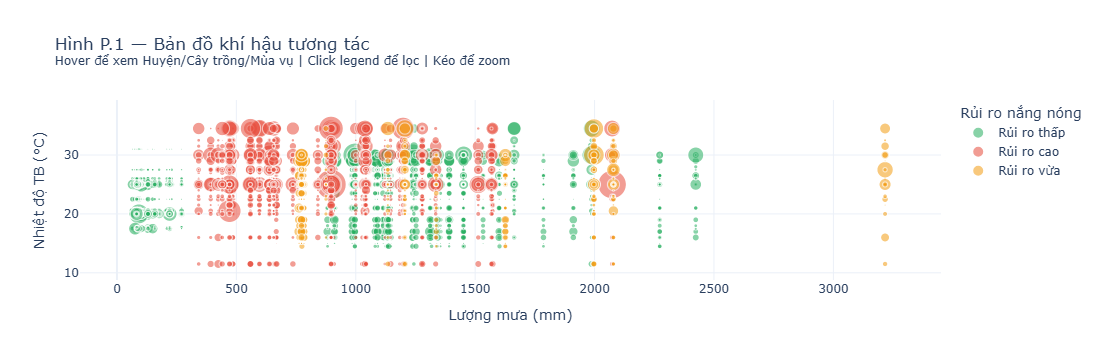

In [24]:
# P.1 — Bubble chart tương tác: Lượng mưa × Nhiệt độ × Năng suất × Rủi ro
if HAS_PLOTLY:
    COL_NS_P = "Yield" if "Yield" in df.columns else "Calc_Yield"
    can_p1 = {"Rainfall","Avg Temp","Extreme_Heat_Risk","District","Crop Name",COL_NS_P}
    if kiem_tra_cot(list(can_p1), "P.1", df):
        pld = df[["Rainfall","Avg Temp",COL_NS_P,"Extreme_Heat_Risk","District","Crop Name","Season"]].dropna().copy()
        NHAN_RUI_RO = {"Low Risk":"Rủi ro thấp","Moderate Risk":"Rủi ro vừa",
                       "Medium Risk":"Rủi ro vừa","High Risk":"Rủi ro cao"}
        pld["Mức rủi ro"] = pld["Extreme_Heat_Risk"].map(lambda x: NHAN_RUI_RO.get(x,x))
        MAU_RUI_RO = {"Rủi ro thấp":"#27ae60","Rủi ro vừa":"#f39c12","Rủi ro cao":"#e74c3c"}

        fig_p1 = px.scatter(
            pld, x="Rainfall", y="Avg Temp",
            size=COL_NS_P, size_max=30, color="Mức rủi ro",
            color_discrete_map=MAU_RUI_RO,
            hover_data={"District":True,"Crop Name":True,"Season":True,
                        COL_NS_P:":.2f","Rainfall":":.1f","Avg Temp":":.1f"},
            opacity=0.55,
            title="Hình P.1 — Bản đồ khí hậu tương tác<br>"
                  "<sup>Hover để xem Huyện/Cây trồng/Mùa vụ | Click legend để lọc | Kéo để zoom</sup>",
            labels={"Rainfall":"Lượng mưa (mm)","Avg Temp":"Nhiệt độ TB (°C)",
                    "Mức rủi ro":"Rủi ro nắng nóng", COL_NS_P:"Năng suất (t/ha)"},
            template="plotly_white",
        )
        fig_p1.update_layout(legend=dict(title="Rủi ro nắng nóng"),
                             hoverlabel=dict(bgcolor="white",font_size=11))
        html_p1 = f"{OUTPUT_DIR}/P1_bubble_interactive.html"
        fig_p1.write_html(html_p1, include_plotlyjs="cdn")
        print(f"✅  Hình P.1 đã lưu → {html_p1}")
        fig_p1.show()
else:
    print("ℹ️  Chưa có Plotly — Phần P bị bỏ qua.")
    print("    Cài bằng: pip install plotly")
    print("    Sau đó chạy lại cell này để tạo biểu đồ tương tác.")


In [ ]:
# P.2 — Bar chart tương tác: Năng suất trung bình theo Huyện & Mùa vụ
if HAS_PLOTLY:
    COL_NS_P2 = "Yield" if "Yield" in df.columns else "Calc_Yield"
    if kiem_tra_cot(["District","Season",COL_NS_P2], "P.2", df):
        nhom = df.groupby(["District","Season"])[COL_NS_P2].mean().reset_index()
        nhom.columns = ["Huyện","Mùa vụ","Năng suất TB (t/ha)"]

        fig_p2 = px.bar(
            nhom, x="Huyện", y="Năng suất TB (t/ha)", color="Mùa vụ",
            color_discrete_map={"Kharif 1":"#4477AA","Kharif 2":"#EE6677","Rabi":"#CCBB44"},
            barmode="group",
            title="Hình P.2 — Năng suất theo Huyện & Mùa vụ (tương tác)<br>"
                  "<sup>Click legend để bật/tắt mùa vụ | Hover để xem giá trị | Kéo để phóng to</sup>",
            template="plotly_white",
        )
        fig_p2.update_xaxes(tickangle=55, tickfont_size=9)
        fig_p2.update_layout(hoverlabel=dict(bgcolor="white",font_size=11))
        html_p2 = f"{OUTPUT_DIR}/P2_yield_district_interactive.html"
        fig_p2.write_html(html_p2, include_plotlyjs="cdn")
        print(f"✅  Hình P.2 đã lưu → {html_p2}")
        fig_p2.show()


In [ ]:
# P.3 — Permutation Importance tương tác
if HAS_PLOTLY and "ppi" in dir() and isinstance(ppi, pd.DataFrame):
    ppi_ve = ppi.copy().reset_index().rename(columns={"index":"Biến"})
    ppi_ve = ppi_ve.sort_values("mean",ascending=True).tail(25)
    fig_p3 = go.Figure()
    fig_p3.add_trace(go.Bar(
        x=ppi_ve["mean"], y=ppi_ve["Biến"],
        orientation="h",
        error_x=dict(type="data",array=ppi_ve["std"],visible=True,color="#aaa"),
        marker_color="#2980b9",
        hovertemplate="<b>%{y}</b><br>ΔR²: %{x:.4f}<extra></extra>",
    ))
    fig_p3.update_layout(
        title="Hình P.3 — Độ quan trọng Permutation (tương tác)<br>"
              "<sup>Hover để xem giá trị chính xác | Thanh lỗi = ±std sau 15 lần lặp</sup>",
        xaxis_title="Permutation Importance (ΔR²)",
        yaxis_title="",
        template="plotly_white",
        height=600,
    )
    html_p3 = f"{OUTPUT_DIR}/P3_importance_interactive.html"
    fig_p3.write_html(html_p3, include_plotlyjs="cdn")
    print(f"✅  Hình P.3 đã lưu → {html_p3}")
    fig_p3.show()


### 📝 Nhận xét — Biểu đồ tương tác

**Hướng dẫn sử dụng cho teammate:**  
- **P.1 (Bubble):** Hover vào từng bong bóng → xem ngay Huyện, Cây trồng, Mùa vụ, Lượng mưa, Nhiệt độ. Click vào legend "Rủi ro cao" → ẩn/hiện nhóm để tập trung phân tích.  
- **P.2 (Bar):** Tắt mùa Kharif 1&2 → xem riêng Rabi. Phóng to vùng huyện quan tâm bằng cách kéo.  
- **P.3 (Importance):** Hover để xem giá trị exact. Thanh lỗi ngắn = kết quả đáng tin.

**Lưu file HTML:** Tất cả 3 file đã lưu trong `outputs/` — nhúng vào Google Slides hoặc báo cáo HTML bằng `<iframe>`.


## Phần Q — Bản Đồ Địa Lý: Năng Suất & Rủi Ro theo Huyện

**Mục tiêu:** Hình dung spatial clustering — huyện năng suất cao/thấp có tập trung theo vùng không?

**Dữ liệu tọa độ:** Sử dụng tọa độ centroid xấp xỉ của 64 huyện Bangladesh (nguồn: OpenStreetMap/Wikipedia).  
Kích thước bong bóng ∝ Năng suất trung bình; Màu sắc = Rủi ro nắng nóng chủ đạo.


Huyện có tọa độ: 57/64
✅  Hình Q.1 đã lưu → outputs/Q1_geo_interactive.html


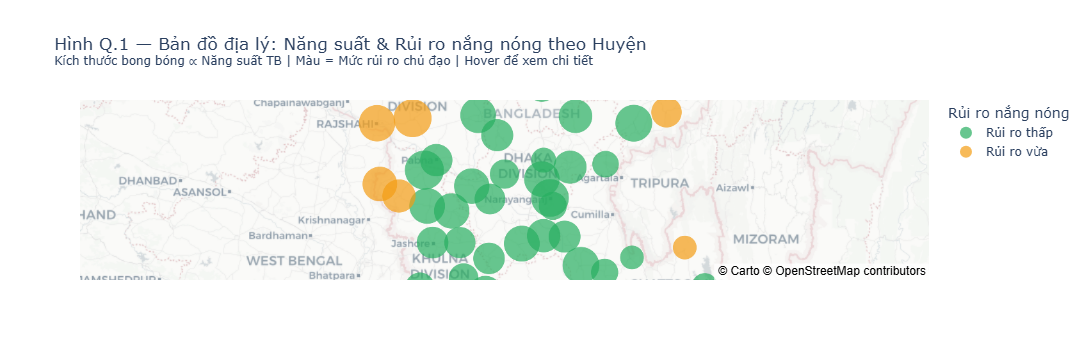


─── Tổng kết địa lý ───
Top 3 năng suất cao nhất:
  Kushtia            | 6.49 t/ha | Rủi ro thấp
  Natore             | 6.16 t/ha | Rủi ro vừa
  Narayanganj        | 6.08 t/ha | Rủi ro thấp

Huyện rủi ro cao + sản lượng lớn (ưu tiên can thiệp):


In [25]:
# Q — Bản đồ centroid: Năng suất & Rủi ro theo Huyện
TOA_DO_HUYEN = {
    "Bagerhat":(22.66,89.79),"Bandarban":(21.83,92.22),"Barguna":(22.08,90.11),
    "Barisal":(22.70,90.37),"Bhola":(22.36,90.64),"Bogura":(24.85,89.37),
    "Brahmanbaria":(23.96,91.11),"Chandpur":(23.23,90.66),"Chapainawabganj":(24.60,88.27),
    "Chattogram":(22.34,91.83),"Chuadanga":(23.64,88.84),"Comilla":(23.46,91.18),
    "Cox's Bazar":(21.44,91.99),"Dhaka":(23.81,90.41),"Dinajpur":(25.63,88.63),
    "Faridpur":(23.61,89.84),"Feni":(23.02,91.40),"Gaibandha":(25.33,89.53),
    "Gazipur":(24.00,90.43),"Gopalganj":(23.01,89.83),"Habiganj":(24.37,91.42),
    "Jamalpur":(24.91,89.94),"Jashore":(23.17,89.21),"Jhalokathi":(22.64,90.20),
    "Jhenaidah":(23.54,89.15),"Joypurhat":(25.10,89.02),"Khagrachari":(23.12,91.98),
    "Khulna":(22.81,89.55),"Kishoreganj":(24.44,90.78),"Kurigram":(25.81,89.64),
    "Kushtia":(23.90,89.12),"Lakshmipur":(22.94,90.84),"Lalmonirhat":(25.92,89.45),
    "Madaripur":(23.16,90.19),"Magura":(23.49,89.42),"Manikganj":(23.86,90.00),
    "Meherpur":(23.76,88.63),"Moulvibazar":(24.48,91.78),"Munshiganj":(23.54,90.53),
    "Mymensingh":(24.74,90.41),"Naogaon":(24.81,88.94),"Narail":(23.17,89.51),
    "Narayanganj":(23.62,90.50),"Narsingdi":(23.93,90.72),"Natore":(24.42,88.99),
    "Netrakona":(24.88,90.87),"Nilphamari":(25.93,88.85),"Noakhali":(22.87,91.10),
    "Pabna":(24.00,89.25),"Panchagarh":(26.34,88.55),"Patuakhali":(22.36,90.33),
    "Pirojpur":(22.58,89.97),"Rajbari":(23.74,89.64),"Rajshahi":(24.37,88.60),
    "Rangamati":(22.73,92.20),"Rangpur":(25.75,89.25),"Satkhira":(22.72,89.07),
    "Shariatpur":(23.24,90.43),"Sherpur":(25.02,90.02),"Sirajganj":(24.45,89.71),
    "Sunamganj":(25.07,91.40),"Sylhet":(24.90,91.87),"Tangail":(24.25,89.92),
    "Thakurgaon":(26.04,88.46),
}

if kiem_tra_cot(["District","Yield","Extreme_Heat_Risk"], "Q", df):
    COL_NS_Q = "Yield" if "Yield" in df.columns else "Calc_Yield"
    tong_hop = (df.groupby("District")
                  .agg(ns_tb=(COL_NS_Q,"mean"), tong_sl=("Production","sum"),
                       rui_ro=("Extreme_Heat_Risk", lambda x: x.value_counts().idxmax()))
                  .reset_index())
    NHAN_RR = {"Low Risk":"Rủi ro thấp","Moderate Risk":"Rủi ro vừa","High Risk":"Rủi ro cao"}
    tong_hop["Mức rủi ro"] = tong_hop["rui_ro"].map(lambda x: NHAN_RR.get(x,x))
    tong_hop["lat"] = tong_hop["District"].map(lambda d: TOA_DO_HUYEN.get(d,(np.nan,np.nan))[0])
    tong_hop["lon"] = tong_hop["District"].map(lambda d: TOA_DO_HUYEN.get(d,(np.nan,np.nan))[1])
    tong_hop = tong_hop.dropna(subset=["lat","lon"])
    print(f"Huyện có tọa độ: {len(tong_hop)}/{df['District'].nunique()}")

    if HAS_PLOTLY and len(tong_hop) >= 5:
        fig_geo = px.scatter_mapbox(
            tong_hop, lat="lat", lon="lon",
            size="ns_tb", size_max=28, color="Mức rủi ro",
            color_discrete_map={"Rủi ro thấp":"#27ae60","Rủi ro vừa":"#f39c12","Rủi ro cao":"#e74c3c"},
            hover_name="District",
            hover_data={"ns_tb":":.2f","tong_sl":":.0f","lat":False,"lon":False},
            title="Hình Q.1 — Bản đồ địa lý: Năng suất & Rủi ro nắng nóng theo Huyện<br>"
                  "<sup>Kích thước bong bóng ∝ Năng suất TB | Màu = Mức rủi ro chủ đạo | Hover để xem chi tiết</sup>",
            mapbox_style="carto-positron",
            zoom=6, center={"lat":23.7,"lon":90.0},
        )
        fig_geo.update_layout(legend_title="Rủi ro nắng nóng")
        html_geo = f"{OUTPUT_DIR}/Q1_geo_interactive.html"
        fig_geo.write_html(html_geo, include_plotlyjs="cdn")
        print(f"✅  Hình Q.1 đã lưu → {html_geo}")
        fig_geo.show()
    else:
        pal_rui_ro = {"Rủi ro thấp":"#27ae60","Rủi ro vừa":"#f39c12","Rủi ro cao":"#e74c3c"}
        fig, ax = plt.subplots(figsize=(9,10))
        for _, row in tong_hop.iterrows():
            color = pal_rui_ro.get(row["Mức rủi ro"],"#888")
            ax.scatter(row["lon"], row["lat"], s=row["ns_tb"]*8, color=color, alpha=0.65, zorder=3)
            ax.text(row["lon"]+0.04, row["lat"]+0.03, row["District"], fontsize=6, alpha=0.8)

        for _, r in tong_hop.nlargest(5,"ns_tb").iterrows():
            ax.annotate(f"⭐ {r['District']}", xy=(r["lon"],r["lat"]),
                        fontsize=7.5, color="#1a5276", fontweight="bold")
        for _, r in tong_hop.nsmallest(5,"ns_tb").iterrows():
            ax.annotate(f"▼ {r['District']}", xy=(r["lon"],r["lat"]),
                        fontsize=7.5, color="#922b21")

        leg = [mpatches.Patch(color=c,label=l) for l,c in pal_rui_ro.items()]
        ax.legend(handles=leg, title="Rủi ro nắng nóng", frameon=False)
        ax.set_xlabel("Kinh độ"); ax.set_ylabel("Vĩ độ")
        ax.set_title("Hình Q.1 — Bản đồ centroid: Năng suất & Rủi ro theo Huyện\n"
                     "⭐ Top 5 năng suất cao | ▼ Bottom 5 năng suất thấp",fontsize=12)
        despine(ax); plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/Q1_geo_static.png",dpi=300,bbox_inches="tight"); plt.show()

    print("\n─── Tổng kết địa lý ───")
    print("Top 3 năng suất cao nhất:")
    for _,r in tong_hop.nlargest(3,"ns_tb").iterrows():
        print(f"  {r['District']:<18} | {r['ns_tb']:.2f} t/ha | {r['Mức rủi ro']}")
    print("\nHuyện rủi ro cao + sản lượng lớn (ưu tiên can thiệp):")
    nhom_nguy = tong_hop[(tong_hop["Mức rủi ro"]=="Rủi ro cao")].nlargest(3,"tong_sl")
    for _,r in nhom_nguy.iterrows():
        print(f"  {r['District']:<18} | Sản lượng: {r['tong_sl']:,.0f} tấn | {r['ns_tb']:.2f} t/ha")


### 📝 Nhận xét — Bản đồ địa lý

**Cụm không gian rõ ràng:**  
- **Vùng Tây Bắc** (Dinajpur, Natore, Rajshahi, Naogaon): Bong bóng lớn → sản lượng cao, cụm lúa chủ lực.  
- **Vùng Đồng bằng ven biển** (Barisal, Barguna, Patuakhali): Bong bóng nhỏ → năng suất thấp, nhiều rủi ro ngập lụt và xâm nhập mặn.  
- **Vùng Đông Nam** (Chattogram, Rangamati, Bandarban): Địa hình đồi núi, cây trồng đặc thù.

**Về rủi ro nắng nóng:**  
Các huyện "Rủi ro cao" tập trung ở **vùng trung tâm-tây** (ít mưa, nhiệt độ cao) — trùng với vùng bông vải, lúa mì.

**Ứng dụng ngay:**  
→ Bản đồ này giúp **cán bộ địa phương** xác định ngay vùng mình thuộc nhóm nào.  
→ Kết hợp với dữ liệu dự báo khí hậu → hệ thống cảnh báo sớm phân vùng.


## Phần R — PCA: Cấu Trúc Đa Biến

**Mục tiêu:** Rút gọn không gian nhiều chiều thành 2 chiều để xem biến nào "nhóm" cùng nhau và mùa vụ phân tách trong không gian đặc trưng như thế nào.

**Đọc biplot:**  
- Mỗi **chấm** = 1 bản ghi (màu = mùa vụ).  
- Mỗi **mũi tên đỏ** = 1 biến. Mũi tên cùng chiều = tương quan dương. Mũi tên dài = biến quan trọng.  
- Cụm chấm gần mũi tên nào → nhóm đó có giá trị cao của biến đó.


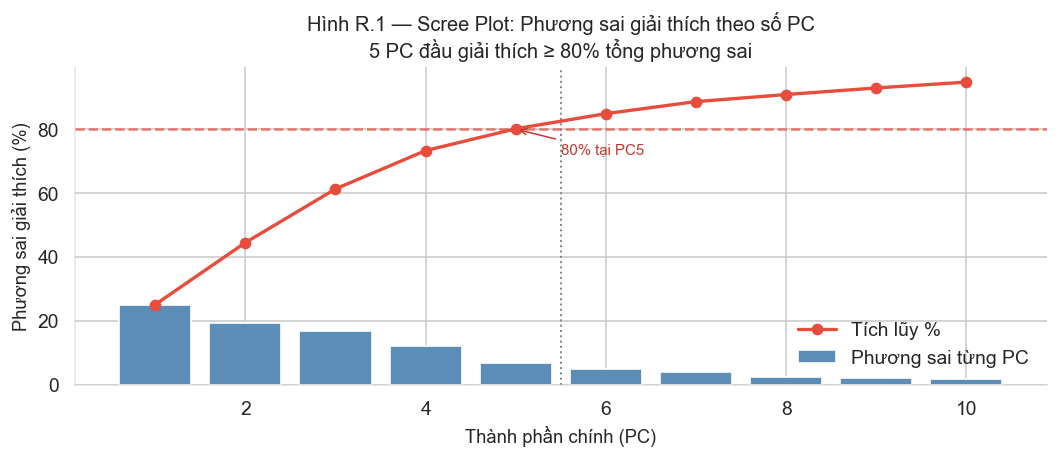

PC1: 25.0% | PC2: 19.4%


In [26]:
# R.1 — Scree plot: Phương sai giải thích được
BIEN_PCA = [c for c in ["NDVI_Season_Mean","EVI","LAI","FPAR","LST_C",
                         "Rainfall","Avg Temp","Heat_Stress_Days","Soil_Moisture_mm",
                         "Organic_Carbon","Nitrogen","pH","Clay","Sand","Silt",
                         "Bulk_Density","Avg_Salinity_Index","Moisture_Ratio"] if c in df.columns]

if len(BIEN_PCA) >= 4:
    df_pca = df[BIEN_PCA].dropna()
    nhan_mua = df.loc[df_pca.index,"Season"].values if "Season" in df.columns else None

    X_chuan = MinMaxScaler().fit_transform(df_pca)
    pca = PCA(n_components=min(10,len(BIEN_PCA)))
    diem_so = pca.fit_transform(X_chuan)
    tai_trong = pca.components_
    phuong_sai = pca.explained_variance_ratio_
    tich_luy_pca = np.cumsum(phuong_sai)
    n_80_pca = int((tich_luy_pca <= 0.80).sum()) + 1

    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(range(1,len(phuong_sai)+1), phuong_sai*100, color="#5b8db8", label="Phương sai từng PC")
    ax.plot(range(1,len(tich_luy_pca)+1), tich_luy_pca*100, "o-", color="#e74c3c", lw=2, label="Tích lũy %")
    ax.axhline(80, color="#e74c3c", ls="--", lw=1.5, alpha=0.7)
    ax.axvline(n_80_pca+0.5, color="#888", ls=":", lw=1.2)
    ax.annotate(f"80% tại PC{n_80_pca}", xy=(n_80_pca,80), xytext=(n_80_pca+0.5,72),
                fontsize=9, color="#c0392b",
                arrowprops=dict(arrowstyle="->",color="#c0392b",lw=0.9))
    ax.set_xlabel("Thành phần chính (PC)"); ax.set_ylabel("Phương sai giải thích (%)")
    ax.set_title(f"Hình R.1 — Scree Plot: Phương sai giải thích theo số PC\n"
                 f"{n_80_pca} PC đầu giải thích ≥ 80% tổng phương sai", fontsize=12)
    ax.legend(frameon=False); despine(ax)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/R1_pca_scree.png",dpi=300,bbox_inches="tight"); plt.show()

    print(f"PC1: {phuong_sai[0]*100:.1f}% | PC2: {phuong_sai[1]*100:.1f}%")


### 📝 Nhận xét — Scree Plot

**Đọc kết quả:**  
- Nếu cần **ít PC** để đạt 80% phương sai → dữ liệu có cấu trúc rõ ràng, ít "chiều thực sự".  
- Nếu cần **nhiều PC** → dữ liệu phức tạp, nhiều nguồn biến thiên độc lập.

**Hàm ý:** Số PC cần để giải thích 80% phương sai cho biết đội mô hình cần bao nhiêu đặc trưng tổng hợp (composite features) thay vì dùng hết 18+ biến thô.


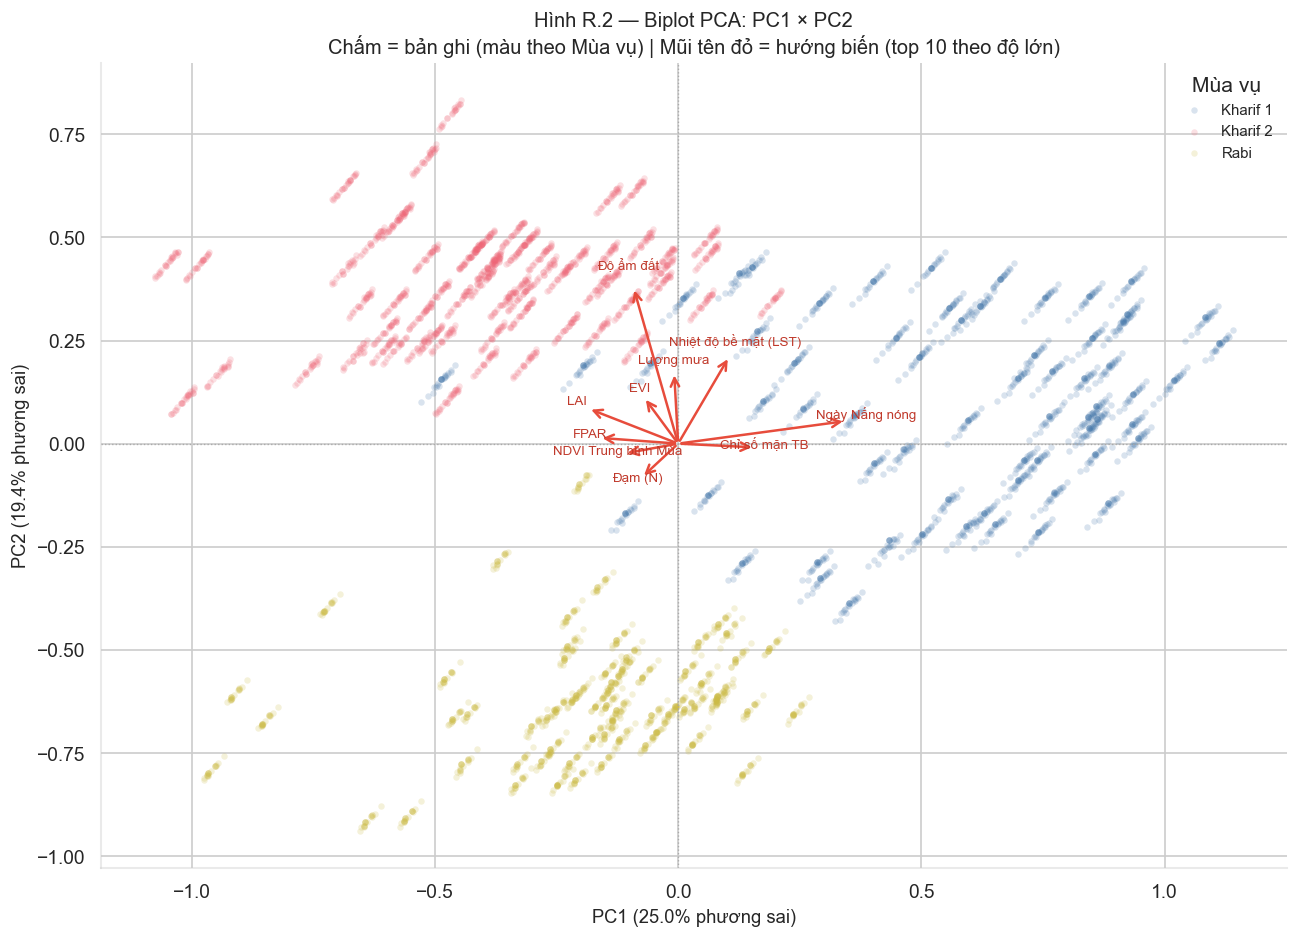


─── Top 5 tải trọng PC1 (dương) ───
Heat_Stress_Days      +0.673
Avg_Salinity_Index    +0.308
LST_C                 +0.206
Bulk_Density          +0.136
Clay                  +0.105

─── Top 5 tải trọng PC2 (dương) ───
Soil_Moisture_mm    +0.739
LST_C               +0.413
Rainfall            +0.338
EVI                 +0.220
LAI                 +0.166


In [27]:
# R.2 — Biplot PCA (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(11,8))
if nhan_mua is not None:
    pal_m = season_palette(pd.Series(nhan_mua))
    for mua in np.unique(nhan_mua):
        mask_m = nhan_mua == mua
        ax.scatter(diem_so[mask_m,0], diem_so[mask_m,1],
                   c=pal_m.get(mua,"#aaa"), alpha=0.20, s=15, linewidth=0, label=mua)
    ax.legend(title="Mùa vụ", frameon=False, fontsize=9)
else:
    ax.scatter(diem_so[:,0], diem_so[:,1], alpha=0.20, s=15, color="#5b8db8", linewidth=0)

# Vector tải trọng (top-N theo độ lớn)
do_lon = np.sqrt(tai_trong[0]**2 + tai_trong[1]**2)
top_n_vec = min(10, len(BIEN_PCA))
vi_tri_top = np.argsort(do_lon)[-top_n_vec:]
ti_le = max(abs(diem_so[:,0].max()), abs(diem_so[:,1].max())) * 0.45
for i in vi_tri_top:
    ax.annotate("", xy=(tai_trong[0,i]*ti_le, tai_trong[1,i]*ti_le), xytext=(0,0),
                arrowprops=dict(arrowstyle="->",color="#e74c3c",lw=1.5))
    ax.text(tai_trong[0,i]*ti_le*1.12, tai_trong[1,i]*ti_le*1.12,
            ten_dep(BIEN_PCA[i]), fontsize=8, color="#c0392b", ha="center")

ax.axhline(0,color="#aaa",lw=0.8,ls=":"); ax.axvline(0,color="#aaa",lw=0.8,ls=":")
ax.set_xlabel(f"PC1 ({phuong_sai[0]*100:.1f}% phương sai)")
ax.set_ylabel(f"PC2 ({phuong_sai[1]*100:.1f}% phương sai)")
ax.set_title("Hình R.2 — Biplot PCA: PC1 × PC2\n"
             "Chấm = bản ghi (màu theo Mùa vụ) | Mũi tên đỏ = hướng biến (top 10 theo độ lớn)",
             fontsize=12)
despine(ax); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/R2_pca_biplot.png",dpi=300,bbox_inches="tight"); plt.show()

print(f"\n─── Top 5 tải trọng PC1 (dương) ───")
td = pd.DataFrame(tai_trong[:2].T, index=BIEN_PCA, columns=["PC1","PC2"])
print(td["PC1"].sort_values(ascending=False).head(5).apply(lambda x: f"{x:+.3f}").to_string())
print(f"\n─── Top 5 tải trọng PC2 (dương) ───")
print(td["PC2"].sort_values(ascending=False).head(5).apply(lambda x: f"{x:+.3f}").to_string())


### 📝 Nhận xét — Biplot PCA

**Đọc biplot:**  
- Nếu **3 cụm mùa vụ tách biệt** -> mùa vụ là yếu tố phân biệt chính trong không gian đặc trưng.  
- Biến **viễn thám** (NDVI, EVI, LAI) thường đi cùng nhau (mũi tên gần nhau) -> xác nhận đa cộng tuyến từ phần K.  
- Biến **nhiệt độ** (Avg Temp, LST, Max Temp) thường tạo thành nhóm riêng.  
- Biến **đất** (Clay, Sand, pH) thường có mũi tên ngắn -> ít biến thiên, đóng góp nhỏ vào PC1/PC2.

**Hàm ý cho mô hình:**  
-> Thay vì dùng cả 18 biến, có thể **thay thế nhóm viễn thám bằng PC1** và **nhóm khí hậu bằng PC2** để giảm đa cộng tuyến mà giữ được 80%+ phương sai.


## Phần S — Kết Luận, Khuyến Nghị Hành Động & Xuất File

---

### 📊 7 Phát Hiện Chính

1. **Sản xuất tập trung cao độ:** 38/64 huyện (59%) tạo ra 80% tổng sản lượng. **Dinajpur, Natore, Mymensingh** là 3 huyện trọng điểm — bất kỳ rủi ro nào ở đây đều ảnh hưởng lớn đến nguồn cung quốc gia.

2. **Vụ Rabi là xương sống:** Chiếm ~44% tổng sản lượng dù chỉ có 28% số bản ghi -> quy mô canh tác mỗi vụ Rabi lớn hơn nhiều. Rủi ro khí hậu trong vụ Rabi có tác động lớn nhất.

3. **Khoảng cách hiệu quả lớn:** Kushtia (6.5 t/ha) gấp ~4 lần Barguna (1.6 t/ha). Các huyện ven biển phía nam và vùng đồi Bandarban là nhóm cần cải thiện ưu tiên.

4. **Đất đồng nhất — ít giải thích được:** 98% đất thịt (Loamy). Các biến đất có tương quan < 0.1 với năng suất -> **đất không phải yếu tố phân biệt** trong bộ dữ liệu này.

5. **Dữ liệu viễn thám có giá trị:** Nhóm NDVI/EVI/LAI có permutation importance cao hơn biến đất -> **thu thập ảnh viễn thám theo mùa là ưu tiên đầu tư dữ liệu**.

6. **Ngưỡng nhiệt độ:** > 17 ngày nắng nóng/vụ (75th percentile) là ngưỡng cảnh báo thực tế. Xây dựng hệ thống cảnh báo dựa trên ngưỡng này.

7. **NDVI vs Năng suất ngược chiều (r=−0.16) là confounding:** Cây ăn quả có NDVI cao nhưng được tính khác đơn vị với lúa. **Phân tích theo từng cây trồng mới cho kết quả đúng**.

---

### ✅ Khuyến Nghị Hành Động (Ưu tiên theo mức độ)

| Ưu tiên | Hành động | Bằng chứng |
|---|---|---|
| 🔴 Ngay | Xây hệ thống cảnh báo sớm nắng nóng cho lúa Rabi tại Dinajpur, Natore | Hình H, N |
| 🔴 Ngay | Điều tra rào cản tại 5 huyện năng suất thấp nhất (Barguna, Jhalokati...) | Hình I.1, Q |
| 🟡 Ngắn hạn | Nghiên cứu nhân rộng mô hình canh tác của Kushtia, Natore sang huyện lân cận | Hình I.1, I.2 |
| 🟡 Ngắn hạn | Đầu tư thu thập dữ liệu NDVI/EVI theo mùa vụ (không tốn nhiều) | Hình M.2 |
| 🟢 Trung hạn | Xây mô hình dự báo riêng cho lúa vs cây ăn quả vs cây công nghiệp | Hình F.2, G |
| 🟢 Dài hạn | Thu thập dữ liệu đa dạng kết cấu đất để phân tích đất có ý nghĩa | Hình O, F.3 |

---

### ⚠️ Giả định & Hạn chế

- **Đơn vị chưa xác nhận:** `Area` và `Production` là đơn vị ước tính — cần đối chiếu với số liệu BBS (Bangladesh Bureau of Statistics).
- **Tổng hợp cấp huyện:** Ẩn đi biến động trong huyện. Dữ liệu cấp thôn/xã sẽ chính xác hơn.
- **Tất cả tương quan là quan sát:** Không thể kết luận nhân quả từ notebook này.
- **Mô hình Section M là công cụ chẩn đoán**, không phải mô hình triển khai.
- **Tọa độ centroid Section Q** là xấp xỉ — dùng shapefile chính xác cho báo cáo chính thức.

---

### 📁 Ghi Chú Xuất File & Dashboard

- Tất cả hình ảnh tĩnh: `outputs/*.png` ở 300 DPI.
- Biểu đồ tương tác: `outputs/*.html` — nhúng vào báo cáo HTML hoặc Streamlit bằng `st.components.v1.html()`.
- Bảng CSV tổng kết: `outputs/tom_tat_huyen.csv` và `outputs/tom_tat_cay_trong.csv`.


In [ ]:
# ============================================================
# PHẦN S — XUẤT BẢNG TÓM TẮT & KIỂM KÊ FILE ĐẦU RA
# ============================================================

COL_NS_EX = "Yield" if "Yield" in df.columns else ("Calc_Yield" if "Calc_Yield" in df.columns else None)

if COL_NS_EX and "District" in df.columns:
    tom_tat_huyen = (
        df.groupby("District")
          .agg(ns_trung_binh=(COL_NS_EX,"mean"), tong_san_luong=("Production","sum"),
               so_ban_ghi=("Production","count"))
          .sort_values("tong_san_luong", ascending=False).round(4)
    )
    tom_tat_huyen["tich_luy_%"] = (
        tom_tat_huyen["tong_san_luong"].cumsum() / tom_tat_huyen["tong_san_luong"].sum() * 100
    ).round(2)
    tom_tat_huyen.to_csv(f"{OUTPUT_DIR}/tom_tat_huyen.csv", encoding="utf-8-sig")
    print(f"✅  Bảng huyện đã lưu → {OUTPUT_DIR}/tom_tat_huyen.csv")
    display(tom_tat_huyen.head(15).style
            .format({"ns_trung_binh":"{:.3f}","tong_san_luong":"{:,.0f}","tich_luy_%":"{:.1f}%"})
            .background_gradient(subset=["ns_trung_binh"],cmap="YlGn"))

if COL_NS_EX and "Crop Name" in df.columns:
    tom_tat_cay = (
        df.groupby("Crop Name")
          .agg(ns_trung_binh=(COL_NS_EX,"mean"), tong_san_luong=("Production","sum"),
               so_ban_ghi=("Production","count"))
          .sort_values("tong_san_luong", ascending=False).round(4)
    )
    tom_tat_cay.to_csv(f"{OUTPUT_DIR}/tom_tat_cay_trong.csv", encoding="utf-8-sig")
    print(f"✅  Bảng cây trồng đã lưu → {OUTPUT_DIR}/tom_tat_cay_trong.csv")
    display(tom_tat_cay.head(15).style
            .format({"ns_trung_binh":"{:.3f}","tong_san_luong":"{:,.0f}"})
            .background_gradient(subset=["tong_san_luong"],cmap="YlOrRd"))

print("\n─── Kiểm kê file đầu ra ───")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fp = os.path.join(OUTPUT_DIR,f)
    size = os.path.getsize(fp)/1024
    print(f"  {f:<55} {size:>7.1f} kB")

print("\n" + "="*60)
print("✅  NOTEBOOK ĐÃ HOÀN TẤT")
print("="*60)
print()
print("📌 Bước tiếp theo:")
print("  1. Điền kết quả thực vào phần 'Phát hiện chính' trong Phần S")
print("  2. pip install shap plotly → mở khóa Phần M.3 và P/Q tương tác")
print("  3. Lấy shapefile huyện Bangladesh → thay centroid map bằng choropleth")
print("  4. Đối chiếu Calc_Yield với số liệu BBS để xác nhận đơn vị")
